In [1]:
%matplotlib inline

import jax.numpy as jnp
from jax import value_and_grad
from jax import random
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import seaborn as snb


from mpl_toolkits.axes_grid1 import make_axes_locatable

def add_colorbar(im, fig, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')


# we want to use 64 bit floating precision
import jax
jax.config.update("jax_enable_x64", True)

snb.set_style('darkgrid')
snb.set_theme(font_scale=1.25)


# 02477 Bayesian Machine Learning: Exercise 5

The purpose of this exercise is to
- learn how to sample from a multivariate Gaussian distribution
- become familiar with covariance functions, especially stationary covariance functions such as the squared exponential and Matérn family and to understand their properties and hyperparameters
- become familiar with Gaussian processes and learn to use them as prior distribution for latent functions in regression settings


**Content**

- Part 1: Sampling from a multivariate Gaussian distribution
- Part 2: Stationary covariance functions
- Part 3: Non-linear regression using Gaussian processes
- Part 4: Hyperparameter optimization using the marginal likelihood
- Part 5: Analysing the bike sharing data set


**Note**: The exercise contains several **discussion questions**, which are questions, where are supposed to actively experiment with the code and/or reason with the equations to arrive at the relevant conclusions. This also means that we won't provide a specific solution for this task. However, you are more than welcome to check your understanding and your conclusions with the TAs. Instead of proving the full description for every discussion question, we simply tag it with: [**Discussion question**] after the question.

# Introduction

When we worked with parametric models such as linear regression and logistic regression, we assigned prior distributions on the weights $\mathbf{w}$ of the models. In contrast, we can think of Gaussian processes as prior distributions directly on the function space

$$\begin{align*}
f(\mathbf{x}) \sim \mathcal{GP}\left(m(\mathbf{x}) \, , \, k\left(\mathbf{x}, \mathbf{x}'\right)\right)
\end{align*}$$

where $f: \mathbb{R}^D \rightarrow \mathbb{R}$ and $\mathbf{m}(\mathbf{x}) = \mathbb{E}\left[f(\mathbf{x})\right]$, and $\mathbf{k}(\mathbf{x}, \mathbf{x}') = \mathbb{E}\left[\left(f(\mathbf{x})-m(\mathbf{x})\right)\left(f(\mathbf{x'})-m(\mathbf{x'})\right)\right]$ are the **mean function** and **covariance function**, respectively, for $\mathbf{x}, \mathbf{x}' \in \mathbb{R}$.


A Gaussian process is completely specified by its mean and covariance function. Most often we take the mean function to be zero, $m(\mathbf{x}) = 0$, because we don't have any prior information on the mean function:

$$\begin{align*}
f(\mathbf{x}) \sim \mathcal{GP}\left(0 \, , \, k\left(\mathbf{x}, \mathbf{x}'\right)\right), \tag{1}
\end{align*}$$

The **covariance function** (or kernel function) $k(\mathbf{x}, \mathbf{x}')$ thus completely determines the a priori behavior of the latent function $f$. Specifically, the covariance function determines the covariance of the latent function $f$ when evaluated at two different inputs, i.e.

$$\begin{align*}
\text{cov}[f(\mathbf{x}), f(\mathbf{x}')] = k(\mathbf{x}, \mathbf{x}'). \tag{2}
\end{align*}$$


The **squared exponential** covariance function is given by

\begin{align*} 
    k_{\text{SE}}(\mathbf{x}_n, \mathbf{x}_m) = \kappa^2 \exp\left(-\frac{\|\mathbf{x}_n - \mathbf{x}_m\|^2_ 2}{2\ell^2}\right), \tag{3}
\end{align*}

where $\kappa > 0$ and $\ell > 0$ are hyperparameters of the kernel. This specific covariance function is perhaps the most common covariance function used in statistics and machine learning. It is also known as the radial basis function kernel, the gaussian kernel, or the exponentiated quadratic kernel. We will also study two covariance functions from the Matérn family:

$$\begin{align*}
k_{\text{Matern12}}(\mathbf{x}_n, \mathbf{x}_m) &= \kappa^2 \exp\left(-\frac{||\mathbf{x}_n- \mathbf{x}_m||}{\ell}\right)\\
k_{\text{Matern32}}(\mathbf{x}_n, \mathbf{x}_m) &= \kappa^2 \left(1 + \frac{\sqrt{3}||\mathbf{x}_n - \mathbf{x}_m||}{\ell}\right)\exp\left(-\frac{\sqrt{3}||\mathbf{x}_n- \mathbf{x}_m||}{\ell}\right).
\end{align*}
$$


_____

## Gaussian Processes as Function Priors

In Bayesian linear and logistic regression we placed priors on the model parameters **w**. A Gaussian process (GP) extends this idea by placing a prior *directly* on the latent function $f:\mathbb{R}^D\to\mathbb{R}$:

$$
f(\mathbf{x}) \sim \mathcal{GP}\!\bigl(m(\mathbf{x}),\, k(\mathbf{x},\mathbf{x}')\bigr).
\tag{1} $$

Mean–covariance specification
-----------------------------

A GP is completely specified by

* **Mean function**  
  $$m(\mathbf{x}) = \mathbb{E}[f(\mathbf{x})]$$

* **Covariance (kernel) function**  
  $$k(\mathbf{x}, \mathbf{x}') = \operatorname{cov}[f(\mathbf{x}), f(\mathbf{x}')] \tag{2}$$

For any finite input set $\{\mathbf{x}_1, \dots, \mathbf{x}_N\}$, the random vector $(f(\mathbf{x}_1), \dots, f(\mathbf{x}_N))^\top$ follows a multivariate Gaussian $\mathcal{N}(\mathbf{m}, K)$ with mean vector components $\mathbf{m}_n = m(\mathbf{x}_n)$ and covariance matrix entries $K_{nm} = k(\mathbf{x}_n, \mathbf{x}_m)$. Thus, equations (1)–(2) encode all prior assumptions about $f$.
$K_{nm} = k(\mathbf{x}_n, \mathbf{x}_m).$   

Thus, equations (1)–(2) encode all prior assumptions about $f$.

### Zero–mean convention

When no prior knowledge about the mean is available we set $m(\mathbf{x})=0$ and let the kernel capture all structure:

$$
f(\mathbf{x}) \sim \mathcal{GP}\!\bigl(0,\, k(\mathbf{x},\mathbf{x}')\bigr).
\tag{3}
$$

Popular covariance functions
----------------------------

### Squared–Exponential / RBF kernel

$$  
k_{\text{SE}}(\mathbf{x}_n,\mathbf{x}_m) =
\sigma_f^{2}\exp\!\Bigl(-\tfrac{\|\mathbf{x}_n-\mathbf{x}_m\|_2^{2}}{2\ell^{2}}\Bigr).
\tag{4}
$$

* $\sigma_f^{2}$ (**signal variance**) controls the vertical scale of function variations.  
* $\ell$ (**length‑scale**) sets the horizontal scale; larger $\ell$ implies smoother, slower‑varying functions.

### Matérn family ($\nu=\tfrac12,\,\tfrac32$)

$$  
\begin{aligned}
k_{\nu=\frac12}(\mathbf{x}_n,\mathbf{x}_m) &=
\sigma_f^{2}\exp\!\Bigl(-\tfrac{\|\mathbf{x}_n-\mathbf{x}_m\|_2}{\ell}\Bigr),\\[4pt]
k_{\nu=\frac32}(\mathbf{x}_n,\mathbf{x}_m) &=
\sigma_f^{2}\Bigl(1+\tfrac{\sqrt3\|\mathbf{x}_n-\mathbf{x}_m\|_2}{\ell}\Bigr)
\exp\!\Bigl(-\tfrac{\sqrt3\|\mathbf{x}_n-\mathbf{x}_m\|_2}{\ell}\Bigr).
\end{aligned}
\tag{5}
$$

The smoothness of draws increases with $\nu$; the Matérn kernel approaches the squared‑exponential as $\nu\to\infty$.

---

**Intuition**

* The kernel value is large when $\mathbf{x}$ and $\mathbf{x}'$ are *similar* under the chosen distance measure, expressing a belief that $f(\mathbf{x})$ and $f(\mathbf{x}')$ should be close.  
* By tuning $\sigma_f$ and $\ell$ (or learning them from data) we adjust our prior belief about the typical amplitude and length‑scale of function variations.

---

This rewrite groups concepts thematically, labels each equation, and gives interpretations for all symbols, helping the reader understand how each piece fits into the GP framework.

$$


# Part 1:  Sampling from a multivariate Gaussian distribution


To become familiar with covariance functions and understand its properties, we will generate and visualize samples from Gaussian process distributions. Therefore, our first order of business will be to implement a function for generating samples from a Gaussian process prior.


Let $\mathbf{X} = \left\lbrace \mathbf{x}_n \right\rbrace_{n=1}^N $ be a set of points in the real line, i.e. $\mathbf{x}_n \in \mathbb{R}^D$, and let $f: \mathbb{R}^D \rightarrow \mathbb{R}$ be a function. Let $f_n \equiv f(x_n) \in \mathbb{R}$ be the value of the function $f$ evaluated at $x_n \in \mathbb{R}$. Furthermore, let $\mathbf{f} \equiv \left[f_1, f_2, \dots, f_N\right] \in \mathbb{R}^{N \times 1}$ be the vector of function values for each of the points in $\mathbf{X}$, then the Gaussian process prior for $\mathbf{f}$ becomes

$$\begin{align*}
\mathbf{f} \sim \mathcal{N}\left(\mathbf{0}, \mathbf{K}\right), \tag{4}
\end{align*}
$$

where $\mathbf{K} \in \mathbb{R}^{N \times N}$ is the kernel matrix satisfying $\mathbf{K}_{nm} = k(\mathbf{x}_n ,\mathbf{x}_m)$, where $\mathbf{x}_n$ refers to the $n$'th input point, i.e. the $i$'th entry of $\mathbf{X}$.

The **Cholesky decomposition** is sometimes refered to as *matrix square root* and it is really handy matrix decomposition for sampling from a multivariate Gaussian distribution. The Cholesky decomposition of the kernel matrix is given by $\mathbf{K} = \mathbf{L}\mathbf{L}^T$, where $\mathbf{L} \in \mathbb{R}^{N \times N}$ is a lower triangular matrix.

The idea is to generate samples from standardized Gaussian distributions, and then transform those samples into the desired distribution. Let $\mathbf{z} \in \mathbb{R}^{N \times 1}$ be a sample from a standardized multivariate Gaussian distribution, i.e. $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_n)$, where $\mathbf{I}_n$ is the identity matrix of size $N \times N$.

___________________________________


# Part 1: Sampling from a Multivariate Gaussian Distribution


## Gaussian Processes as Function Priors

In Bayesian linear and logistic regression we placed priors on the model parameters **w**. A Gaussian process (GP) extends this idea by placing a prior *directly* on the latent function $f:\mathbb{R}^D\to\mathbb{R}$:

$$
f(\mathbf{x}) \sim \mathcal{GP}\!\bigl(m(\mathbf{x}),\, k(\mathbf{x},\mathbf{x}')\bigr). \tag{1}$$

Mean–covariance specification
-----------------------------

A GP is completely specified by

* **mean function**  
  $m(\mathbf{x}) = \mathbb{E}[f(\mathbf{x})]$, (2)
* **Covariance (kernel) function**  
  $k(\mathbf{x}, \mathbf{x}') = \operatorname{Cov}\left[f(\mathbf{x}), f(\mathbf{x}')\right]$ (2)


For any finite input set $\{\mathbf{x}_1,\dots,\mathbf{x}_N\}$ the random vector $(f(\mathbf{x}_1),\dots,f(\mathbf{x}_N))^\top$ follows the multivariate Gaussian $\mathcal{N}(\mathbf{m}, K)$ with mean vector $\mathbf{m}_n=m(\mathbf{x}_n)$ and covariance matrix $K_{nm}=k(\mathbf{x}_n,\mathbf{x}_m)$. Thus equations (1)–(2) encode all prior assumptions about $f$.

### Zero–mean convention

When no prior knowledge about the mean is available we set $m(\mathbf{x})=0$ and let the kernel capture all structure:

$$
f(\mathbf{x}) \sim \mathcal{GP}\!\bigl(0,\, k(\mathbf{x},\mathbf{x}')\bigr).
\tag{3}
$$

Popular covariance functions
----------------------------

### Squared–Exponential / RBF kernel

$$
k_{\text{SE}}(\mathbf{x}_n,\mathbf{x}_m) =
\sigma_f^{2}\exp\!\Bigl(-\tfrac{\|\mathbf{x}_n-\mathbf{x}_m\|_2^{2}}{2\ell^{2}}\Bigr).
\tag{4}
$$

* $\sigma_f^{2}$ (**signal variance**) controls the vertical scale of function variations.  
* $\ell$ (**length‑scale**) sets the horizontal scale; larger $\ell$ implies smoother, slower‑varying functions.

### Matérn family ($\nu=\tfrac12,\,\tfrac32$)

$$
\begin{aligned}
k_{\nu=\frac12}(\mathbf{x}_n,\mathbf{x}_m) &=
\sigma_f^{2}\exp\!\Bigl(-\tfrac{\|\mathbf{x}_n-\mathbf{x}_m\|_2}{\ell}\Bigr),\\[4pt]
k_{\nu=\frac32}(\mathbf{x}_n,\mathbf{x}_m) &=
\sigma_f^{2}\Bigl(1+\tfrac{\sqrt3\|\mathbf{x}_n-\mathbf{x}_m\|_2}{\ell}\Bigr)
\exp\!\Bigl(-\tfrac{\sqrt3\|\mathbf{x}_n-\mathbf{x}_m\|_2}{\ell}\Bigr).
\end{aligned}
\tag{5}$$

The smoothness of draws increases with $\nu$; the Matérn kernel approaches the squared‑exponential as $\nu\to\infty$.

---

**Intuition**

* The kernel value is large when $\mathbf{x}$ and $\mathbf{x}'$ are *similar* under the chosen distance measure, expressing a belief that $f(\mathbf{x})$ and $f(\mathbf{x}')$ should be close.
* By tuning $\sigma_f$ and $\ell$ (or learning them from data) we adjust our prior belief about the typical amplitude and length‑scale of function variations.


Part 1  Sampling from a Gaussian‑process prior
=============================================

The kernel not only encodes *what* we believe about a function but also lets us *generate* concrete examples consistent with that belief. Suppose we have an input set $\mathbf{X}=\{\mathbf{x}_1,\dots,\mathbf{x}_N\}\subset\mathbb{R}^D$ and evaluate the GP prior at those points:

$$
\mathbf{f} \;\stackrel{\text{def}}{=}\; \bigl(f(\mathbf{x}_1),\dots,f(\mathbf{x}_N)\bigr)^\top \sim \mathcal{N}(\mathbf{0},\,\mathbf{K}),\tag{6}
$$

where the *kernel matrix* $\mathbf{K}\in\mathbb{R}^{N\times N}$ has entries

$$
K_{nm}=k(\mathbf{x}_n,\,\mathbf{x}_m).\tag{7}
$$

### Cholesky sampling

A numerically stable way to draw $\mathbf{f}$ is via the Cholesky decomposition:

1. Compute $\mathbf{K}=\mathbf{L}\mathbf{L}^\top$ with $\mathbf{L}$ lower‑triangular.
2. Sample $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I}_N)$.
3. Set $\boxed{\;\mathbf{f}=\mathbf{L}\,\mathbf{z}\;}$. (8)

Because $\mathbf{L}\mathbf{z}$ has mean zero and covariance $\mathbf{L}\mathbf{L}^\top=\mathbf{K}$, the resulting vector is a valid draw from the desired distribution. Adding a small *jitter* term $\epsilon\mathbf{I}$ to $\mathbf{K}$ (e.g. $\epsilon=10^{-6}$) guarantees that it is numerically positive‑definite.


This transformation ensures that $\mathbf{f} \sim \mathcal{N}(\mathbf{0}, \mathbf{K})$ because:

$$
\mathbb{E}[\mathbf{f}] = \mathbb{E}[\mathbf{L} \mathbf{z}] = \mathbf{L} \cdot \mathbb{E}[\mathbf{z}] = \mathbf{0},
$$

and

$$
\operatorname{cov}[\mathbf{f}] = \mathbb{E}[\mathbf{f}\mathbf{f}^\top] = \mathbf{L} \mathbb{E}[\mathbf{z} \mathbf{z}^\top] \mathbf{L}^\top = \mathbf{L} \mathbf{I}_N \mathbf{L}^\top = \mathbf{K}.
$$
______

### Worked example (1‑D RBF kernel)

```python
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """Radial Basis Function (RBF) kernel using JAX."""
    sqdist = jnp.sum(X1**2, axis=1).reshape(-1, 1) + \
             jnp.sum(X2**2, axis=1) - 2 * jnp.dot(X1, X2.T)
    return variance * jnp.exp(-0.5 / lengthscale**2 * sqdist)

# Input locations (1D)
X = jnp.linspace(-5, 5, 100).reshape(-1, 1)

# Compute the kernel matrix
K = rbf_kernel(X, X) + 1e-6 * jnp.eye(len(X))  # Add jitter

# Cholesky decomposition
L = jnp.linalg.cholesky(K)

# Random key for sampling
key = jax.random.PRNGKey(0)
z = jax.random.normal(key, shape=(len(X),))

# Sample from the GP prior
f = jnp.dot(L, z)

# Convert to NumPy for plotting
X_np = jnp.array(X).reshape(-1)
f_np = jnp.array(f)

# Plot
plt.plot(X_np, f_np, label="GP Sample (JAX)")
plt.title("Sample from GP Prior (JAX)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

```

*What to expect.* The three coloured curves are smooth with similar length‑scale (≈ 0.3) and amplitude (≈ ±σ\_f). Changing $\ell$ stretches or compresses them horizontally; increasing $\sigma_f$ scales them vertically.

### Exercise: try a Matérn kernel

Replace `k_rbf` with a Matérn‑$\nu=\tfrac32$ kernel, keeping the same grid. Do the sampled functions look less smooth? Play with $\ell$ and observe how the roughness changes.


---

> **Take‑away.** Visual sampling is a powerful sanity check: if the draws do *not* look like functions you believe a‑priori, revisit the kernel choice or its hyper‑parameters.




____________________________________________


 

**Task 1.1**: Show that if $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_n)$ and $\mathbf{m} \in \mathbb{R}^{N}$, then $\mathbf{f} = \mathbf{L}\mathbf{z} + \mathbf{m} \sim \mathcal{N}(\mathbf{m}, \mathbf{K})$. 




_____

All real-valued symmetric and positive definite matrices have a unique Cholesky decomposition. However, due to finite precision in computers, the covariance matrices used in Gaussian processes can sometimes have negative eigenvalues in practice and hence fail to be positive definite. A common trick is to add a small positive number $\epsilon > 0$ to the diagonal of the covariance matrix, which will increase the eigenvalues of the covariance matrix $\mathbf{K}$ and hence change the sign of a potential small negative eigenvalue. Hence, in practice we construct the covariance matrix as:

In theory, covariance matrices built from valid kernels are positive semi‑definite. In finite precision arithmetic, however, they can become numerically indefinite (e.g., because of near‑duplicate inputs or extreme hyperparameters), and a Cholesky factorization may fail. A standard fix is to add a small jitter (also called diagonal loading or the nugget) to the diagonal:

$$\tilde{\mathbf{K}} = \mathbf{K} + \epsilon \mathbf{I}, \epsilon > 0.$$

If $K = Q \Lambda Q^\top$ is the eigendecomposition of $\mathbf{K}$, then the jittered covariance matrix becomes,

$$\tilde{\mathbf{K}} = Q(\Lambda + \epsilon \mathbf{I})Q^\top,$$

so every eigenvalue is increased by $\epsilon$, guaranteeing strict positive definiteness when $\epsilon$ is larger than the magnitude of any small negative eigenvalue introduced by roundoff.

Entrywise, this is sometimes written with the Kronecker delta


$$
\begin{align*}
\mathbf{K}_{nm}  = k(\mathbf{x}_n, \mathbf{x}_m) + \epsilon \delta(\mathbf{x}_n-\mathbf{x}_m),
\end{align*}
$$

where $\delta(\cdot)$ is **Kronenecker's delta function** defined by 

$$\begin{align*}
\delta(\mathbf{x}_n-\mathbf{x}_m) = \begin{cases} 1 & \text{if}\quad \mathbf{x}_n=\mathbf{x}_m \\ 0 & \text{otherwise} \end{cases}
\end{align*}
$$

We often say we add **jitter** to the covariance matrix. $\epsilon$ should be as small as positive to avoid affecting the results, e.g. a typical number is $\epsilon \approx 10^{-8}$. If $\epsilon$ needs to be significantly bigger, then it is likely that there are some other implementation issues, which should be addressed.


**Interpretational note**

Adding $\epsilon \mathbf{I}$ is equivalent to assuming additional i.i.d. Gaussian observation noise with variance $\epsilon$. If you already model noise with $\sigma_n^2 \mathbf{I}$, you can think of jitter as a tiny extra floor on $\sigma_n^2$ for numerical stability.

_______





**Task 1.2**: **(optional)** Can you prove that adding jitter increases the eigenvalues of the resulting matrix?




**Task 1.3**: Complete the implementation of the function `generate_samples` below for sampling from a multivariate Gaussian using the method described above. 

*Hints*:
- *The function jnp.linalg.cholesky is handy for computing the Cholesky decomposition of a matrix.*
- *You need to add the jitter before computing the Cholesky decomposition.*
- *The argument `key` is for controlling the random number generator in JaX. Sampling is an inherently stochastic procedure, but the explicit use of such keys allows us to build reproducible code in the sense that if we provide the same key, we get the same output.*

In [2]:
import jax.numpy as jnp
from jax import random

def generate_samples(key, m, K, num_samples, jitter=1e-8):
    r"""
    Draw samples from a multivariate Gaussian :math:`\mathcal{N}(m, K)` using the
    Cholesky factorization with optional diagonal jitter for numerical stability.

    **Mathematics**

    Let :math:`L` be the lower-triangular Cholesky factor of
    :math:`K + \epsilon I`, i.e.
    :math:`L L^\top = K + \epsilon I`.

    If :math:`z \sim \mathcal{N}(0, I)`, then

    .. math::

        f = m + L z \sim \mathcal{N}(m, K + \epsilon I).

    When `num_samples = M`, we sample a matrix
    :math:`Z \in \mathbb{R}^{N \times M}` whose columns are i.i.d.
    :math:`\mathcal{N}(0, I)`, and return

    .. math::

        F = m \mathbf{1}^\top + L Z \in \mathbb{R}^{N \times M}.

    Parameters
    ----------
    key : jax.random.PRNGKey
        Random key controlling the RNG (reproducibility).
    m : array_like, shape (N,)
        Mean vector of the Gaussian.
    K : array_like, shape (N, N)
        Covariance (kernel) matrix.
    num_samples : int
        Number of samples :math:`M` to generate.
    jitter : float, optional (default=1e-8)
        Non-negative scalar added to the diagonal of `K` before the Cholesky
        factorization to ensure positive definiteness numerically.

    Returns
    -------
    f_samples : jnp.ndarray, shape (N, M)
        Matrix whose columns are i.i.d. samples from
        :math:`\mathcal{N}(m, K + \epsilon I)`.

    Notes
    -----
    - If you need a significantly large `jitter` (e.g. > 1e-3 relative to the
      scale of `K`), that often indicates numerical pathologies (duplicate inputs,
      extreme hyperparameters, etc.).
    - Shapes:
        * `m`: (N,)
        * `K`: (N, N)
        * `Z`: (N, M)
        * `L`: (N, N)
        * `f_samples`: (N, M)

    Examples
    --------
    >>> key = random.PRNGKey(1)
    >>> num_samples = 100_000
    >>> m = jnp.array([jnp.pi, jnp.sqrt(2.0)])
    >>> V = jnp.array([[0.123, -0.05], [-0.05, 0.123]])
    >>> f_samples = generate_samples(key, m, V, num_samples)
    >>> # Check sample mean and covariance are close to the target:
    >>> assert jnp.linalg.norm(jnp.mean(f_samples, axis=1) - m) < 1e-2
    >>> assert jnp.linalg.norm(jnp.cov(f_samples) - V) < 1e-2
    """
    # Convert to JAX arrays (no-ops if already so)
    m = jnp.asarray(m)
    K = jnp.asarray(K)

    # -------------------------
    # Sanity checks on shapes
    # -------------------------
    assert m.ndim == 1, f"`m` must be a 1-D vector, got shape {m.shape}"
    assert K.ndim == 2 and K.shape[0] == K.shape[1], \
        f"`K` must be a square matrix, got shape {K.shape}"
    N = K.shape[0]
    assert m.shape[0] == N, \
        f"Length of `m` ({m.shape[0]}) must match K.shape[0] ({N})"
    assert num_samples > 0, "`num_samples` must be a positive integer"
    assert jitter >= 0, "`jitter` must be non-negative"

    # ---------------------------------------
    # 1) Sample Z ~ N(0, I), shape (N, M)
    # ---------------------------------------
    Z = random.normal(key, shape=(N, num_samples))

    # ---------------------------------------
    # 2) Cholesky of K + epsilon I
    #    L has shape (N, N)
    # ---------------------------------------
    L = jnp.linalg.cholesky(K + jitter * jnp.eye(N))

    # ---------------------------------------
    # 3) f = m[:, None] + L @ Z
    #    m[:, None] broadcasts to (N, M)
    # ---------------------------------------
    f_samples = m[:, None] + L @ Z

    # ---------------------------------------
    # 4) Final shape check
    # ---------------------------------------
    assert f_samples.shape == (N, num_samples), \
        (f"The shape of f_samples appears wrong. Expected shape ({N}, {num_samples}), "
         f"but got {f_samples.shape}. Please check your code.")

    return f_samples



# sanity check of implementation
key = random.PRNGKey(1)
num_samples = 100000
m = jnp.array([jnp.pi, jnp.sqrt(2)])
V = jnp.array([[0.123, -0.05], [-0.05, 0.123]])
f_samples = generate_samples(key, m, V, num_samples)
assert jnp.linalg.norm(jnp.mean(f_samples, 1)- m) < 1e-2, "The mean of f_samples appears wrong. Please check your code"
assert jnp.linalg.norm(jnp.cov(f_samples) - V) < 1e-2, "The covariance of f_samples appears wrong. Please check your code"

We will use this function in the next section to generate samples from a Gaussian process.

# Part 2:  Stationary covariance functions

Next, we will dive deeper into the covariance functions and their properties. We will focus on so-called **stationary** covariance functions.

> The squared exponential kernel is an example of a **stationary** kernel, which means that the covariance function only depends on the difference between two points, i.e. $\tau = \mathbf{x}_n - \mathbf{x}_m$ for two points in the input space $\mathbf{x}_n, \mathbf{x}_m \in \mathbb{R}^D$:

$$\begin{align*}
    k_{\text{SE}}(\mathbf{x}_n, \mathbf{x}_m) = \kappa^2 \exp\left(-\frac{\|\mathbf{x}_n - \mathbf{x}_m\|^2_ 2}{2\ell^2}\right) = \kappa^2 \exp\left(-\frac{\|\tau\|^2_ 2}{2\ell^2}\right) = k(\tau).
\end{align*}$$

>  Furthermore, if the covariance function only depends on the distance between any two inputs, i.e. $||\tau||_2 = ||\mathbf{x}_n - \mathbf{x}_m||_2$, then the covariance function is also said to be **isotropic** (isotropic is a fancy word for rotation invariance). For the squared exponential kernel we can write:

$$\begin{align*}
    k_{\text{SE}}(\mathbf{x}_n, \mathbf{x}_m) = k(||\tau||) =  \kappa^2 \exp\left(-\frac{\|\tau\|^2_ 2}{2\ell^2}\right), \tag{5}
\end{align*}$$

which shows that the squared exponential kernel is both **stationary** and **isotropic** since it can be written as a function $\|\tau\|$. Note that we in the above overload and abuse the notation of $k$ a bit.

Consider the following four covariance functions: the linear kernel, the Matern $\frac12$ kernel, the Matern $\frac32$ kernel and the so-called automatic relevance determination (ARD) kernel given by

$$\begin{align*}
k_{\text{Linear}}(\mathbf{x}_n, \mathbf{x}_m) &= \alpha^{-1} \mathbf{x}^T_m \mathbf{x}_n\\
k_{\text{Matern12}}(\mathbf{x}_n, \mathbf{x}_m) &= \kappa^2 \exp\left(-\frac{||\mathbf{x}_n- \mathbf{x}_m||}{\ell}\right)\\
k_{\text{Matern32}}(\mathbf{x}_n, \mathbf{x}_m) &= \kappa^2 \left(1 + \frac{\sqrt{3}||\mathbf{x}_n - \mathbf{x}_m||}{\ell}\right)\exp\left(-\frac{\sqrt{3}||\mathbf{x}_n- \mathbf{x}_m||}{\ell}\right)\\
k_{\text{ARD}}(\mathbf{x}_n, \mathbf{x}_m) &= \kappa^2 \exp\left(-\frac12 \sum_{i=1}^D \frac{(\mathbf{x}_{n,i} -\mathbf{x}_{m,i})^2}{\ell_i}\right)  = \kappa^2 \exp\left(-\frac12 (\mathbf{x}_n- \mathbf{x}_m)^T \mathbf{L} \left(\mathbf{x}_n- \mathbf{x}_m)\right)\right),  
\end{align*}$$

where $\mathbf{L} \in \mathbf{R}^{D \times D}$ is a diagonal matrix $\mathbf{L} = \text{diag}(\ell^2_1, \ell^2_2, \dots, \ell^2_D)$. The ARD-kernel can be seen as a generalization of the squared exponential kernel, where each dimension of $\mathbf{x}$ has a separate characteristic lengthscale. 

__________________________________________________



### 1) State stationarity & isotropy as invariances

- **Stationary:** $k(\mathbf x,\mathbf x')=\psi(\mathbf x-\mathbf x')$  
  $\Leftrightarrow$ $k(\mathbf x+\mathbf a,\mathbf x'+\mathbf a)=k(\mathbf x,\mathbf x')$ for all $\mathbf a\in\mathbb R^D$.

- **Isotropic:** $k(\mathbf x,\mathbf x')=\phi\!\big(\lVert \mathbf x-\mathbf x'\rVert_2\big)$  
  $\Leftrightarrow$ $k(Q\mathbf x,Q\mathbf x')=k(\mathbf x,\mathbf x')$ for all orthogonal $Q$ (i.e., $Q^\top Q=I$).

Let $\tau=\mathbf x-\mathbf x'$ and $r=\lVert\tau\rVert_2$. We will reuse $r$ and $\tau$ below.

---

### 2) Unify notation and hyperparameters

- Use a common amplitude $\kappa^2>0$ across kernels.
- Use $\ell>0$ for (isotropic) lengthscales and $\ell_i>0$ for ARD lengthscales.
- Write kernels in terms of $r$ to make stationarity/isotropy obvious.

**Examples (notational rewrites):**
$$
\begin{aligned}
k_{\text{SE}}(r) &= \kappa^2 \exp\!\left(-\frac{r^2}{2\ell^2}\right),\\[4pt]
k_{\text{Mat\kern0.5pt ern}\,\tfrac12}(r) &= \kappa^2 \exp\!\left(-\frac{r}{\ell}\right),\\[4pt]
k_{\text{Mat\kern0.5pt ern}\,\tfrac32}(r) &= \kappa^2 \left(1+\frac{\sqrt{3}\,r}{\ell}\right)\exp\!\left(-\frac{\sqrt{3}\,r}{\ell}\right).
\end{aligned}
$$

---

### 3) Fix and clarify the ARD form

A consistent ARD (SE) kernel is
$$
k_{\text{ARD}}(\mathbf x,\mathbf x') \;=\; \kappa^2 \exp\!\left(
-\tfrac12 \sum_{i=1}^D \frac{(\mathbf x_i-\mathbf x'_i)^2}{\ell_i^{\,2}}
\right)
\;=\;
\kappa^2 \exp\!\left(-\tfrac12\,\tau^\top \Lambda\,\tau\right),
$$
with $\Lambda=\mathrm{diag}(\ell_1^{-2},\ldots,\ell_D^{-2})$.

- **Stationary:** yes (depends only on $\tau$).  
- **Isotropic:** only if all $\ell_i$ are equal (then it reduces to SE).  
- Interpretable as SE under the **Mahalanobis distance** $r_\Lambda=\sqrt{\tau^\top\Lambda\tau}$.  
- As $\ell_i\!\to\!\infty$, dimension $i$ becomes irrelevant.

---

### 4) At‑a‑glance comparison

| Kernel | Depends on | Stationary? | Isotropic? | Smoothness of GP sample paths |
|---|---|---:|---:|---|
| Linear $k(\mathbf x,\mathbf x')=\kappa^2\,\mathbf x^\top\mathbf x'$ | absolute positions | No | No | — (non‑stationary) |
| Matérn‑1/2 $k(r)=\kappa^2 e^{-r/\ell}$ | $r$ | Yes | Yes | rough (not mean‑square differentiable) |
| Matérn‑3/2 $k(r)=\kappa^2 (1+\sqrt{3}r/\ell)e^{-\sqrt{3}r/\ell}$ | $r$ | Yes | Yes | once mean‑square differentiable |
| Squared Exp. $k(r)=\kappa^2 e^{-r^2/(2\ell^2)}$ | $r$ | Yes | Yes | infinitely mean‑square differentiable |
| ARD SE $k(\tau)=\kappa^2 e^{-\tfrac12 \tau^\top\Lambda\tau}$ | $\tau$ | Yes | Usually no | like SE (very smooth) |

---

### 5) Tiny proofs / intuition snippets

- **Why the linear kernel is not stationary:**  
  $$
  k(\mathbf x+\mathbf a,\mathbf x'+\mathbf a)
  =\kappa^2\!\left(\mathbf x^\top\mathbf x' + \mathbf a^\top\mathbf x + \mathbf a^\top\mathbf x' + \mathbf a^\top\mathbf a\right)
  \neq k(\mathbf x,\mathbf x') \text{ in general.}
  $$

- **SE as Matérn limit:**  
  The SE kernel is the Matérn family limit as $\nu\to\infty$, explaining its extreme smoothness.

- **Units check:**  
  $\ell$ and $\ell_i$ have the same units as the inputs; $\Lambda$ has units of (input units)$^{-2}$.  
  This keeps the exponential argument dimensionless.

---

### 6) Optional spectral aside

By **Bochner’s theorem**, every stationary kernel is the Fourier transform of a non‑negative spectral density.  
SE has a Gaussian spectrum; Matérn corresponds to a rational (Student‑t–like) spectrum, connecting $\ell$ and $\nu$ to correlation decay and smoothness.


___________________________





**Task 2.1**: Which of the four kernels above are stationary kernels and which isotropic kernels?





Next, we will implement the squared exponential kernel, the Matérn $\frac{1}{2}$, and the Matérn $\frac{3}{2}$ kernel. The and the cell below provide an implementation of these kernels expressed as a function norm of the distance of the inputs, $||\tau|| = ||\mathbf{x}_n - \mathbf{x}_m||$, e.g. 

$$\begin{align*}
k_{\text{SE}}(||\tau||) = \kappa^2 \exp\left(-\frac{\|\tau\|^2_ 2}{2\ell^2}\right).
\end{align*}$$


________________________

In [3]:
# in the code below tau represents the distance between to input points, i.e. tau = ||x_n - x_m||.
def squared_exponential(tau, kappa, lengthscale):
    return kappa**2*jnp.exp(-0.5*tau**2/lengthscale**2)

def matern12(tau, kappa, lengthscale):
    return kappa**2*jnp.exp(-tau/lengthscale)

def matern32(tau, kappa, lengthscale):
    return kappa**2*(1 + jnp.sqrt(3)*tau/lengthscale)*jnp.exp(-jnp.sqrt(3)*tau/lengthscale)

Below you are given a vector $\mathbf{X} \in \mathbb{R}^{N \times 1}$ of $N = 1000$ points on the real line. The points are sorted and equidistantly distributed in the interval $\left[-6, 6\right]$.

In order to construct the kernel matrices, all we need to do now is to implement some code for evaluating all the pairwise distances, i.e. $||\mathbf{x}_n - \mathbf{x}_m||$ for all pairs of input points, and then feed these distances to the covariance function above along with values for the hyperparameters. This "two-step" implementation makes it easy to switch between different covariance functions. 

> **Task 2.2**: Complete the implementation of the class *StationaryIsotropicKernel* below.

*Hints: The function `construct_kernel` contain three steps:*

1) *compute all the pairwise distances between `X1` and `X2`,*

2) *feed these distance to the covariance function `kernel_fun`,*

3) *add jitter if needed*

- *You can either compute the pairwise distances using for-loops or using a vectorized solution. Using for-loops is a bit slower, but might be easier to understand and debug*

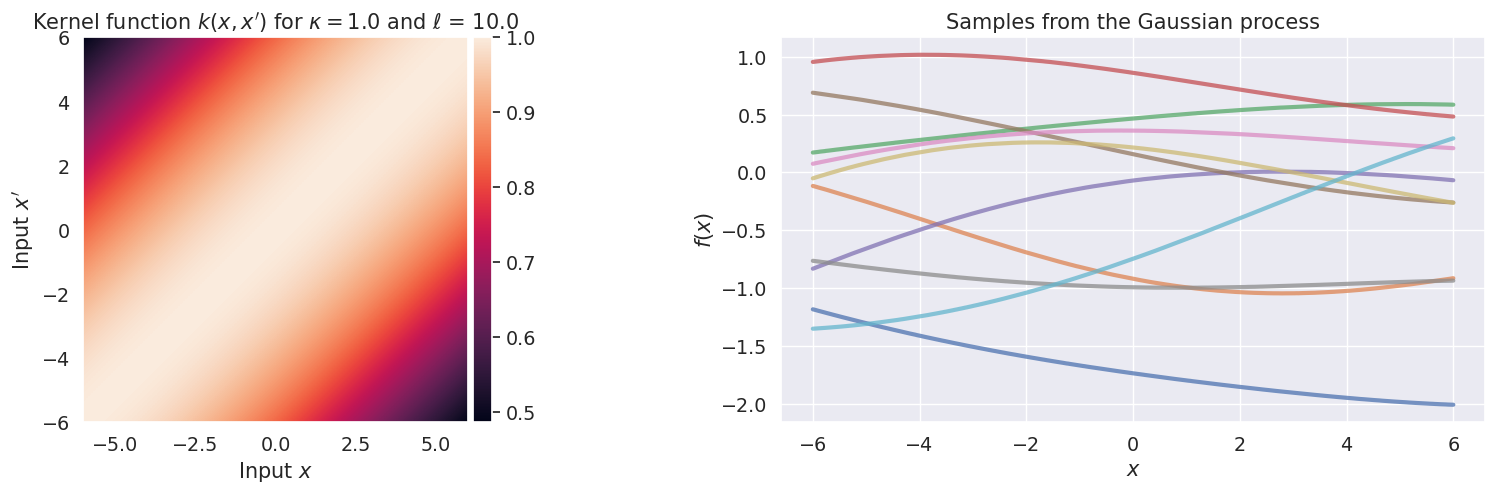

In [68]:
class StationaryIsotropicKernel(object):

    def __init__(self, kernel_fun, kappa=1., lengthscale=1.0):
        """
            the argument kernel_fun must be a function of three arguments kernel_fun(||tau||, kappa, lengthscale), e.g. 
            squared_exponential = lambda tau, kappa, lengthscale: kappa**2*np.exp(-0.5*tau**2/lengthscale**2)
        """
        self.kernel_fun = kernel_fun
        self.kappa = kappa
        self.lengthscale = lengthscale

    def contruct_kernel(self, X1, X2, kappa=None, lengthscale=None, jitter=1e-8):
        """ compute and returns the NxM kernel matrix between the two sets of input X1 (shape NxD) and X2 (MxD) using the stationary and isotropic covariance function specified by self.kernel_fun
    
        arguments:
            X1              -- NxD matrix
            X2              -- MxD matrix
            kappa           -- magnitude (positive scalar)
            lengthscale     -- characteristic lengthscale (positive scalar)
            jitter          -- non-negative scalar
        
        returns
            K               -- NxM matrix    
        """

        # extract dimensions 
        N, M = X1.shape[0], X2.shape[0]

        # prep hyperparameters
        kappa = self.kappa if kappa is None else kappa
        lengthscale = self.lengthscale if lengthscale is None else lengthscale

        ##############################################
        # Your solution goes here
        ##############################################
        # compute all the pairwise distances efficiently
        dist = jnp.sqrt( jnp.sum( (jnp.expand_dims(X1, axis=1) - jnp.expand_dims(X2, axis=0))**2, axis=-1 ) )
        
        # squared exponential covariance function 
        K = self.kernel_fun(dist, kappa, lengthscale)
        #print(f"Ratio of kappa and lengthscale: {kappa/lengthscale:.2f}")
        #print("Value of K:", K)
        # add jitter to diagonal for numerical stability 
        if len(X1) == len(X2) and jnp.allclose(X1, X2):
            K = K + jitter * jnp.identity( len(X1) )
        ##############################################
        # End of solution
        ##############################################
        
        assert K.shape == (N, M), f"The shape of K appears wrong. Expected shape ({N}, {M}), but the actual shape was {K.shape}. Please check your code. "
        return K

        
# create an Nx1 vector of equidistant points in [-6, 6]
N = 1000
X = jnp.linspace(-6, 6, N)[:, None]

# hyperparameters
kappa = 1.
scale = 10.

# number of samples to be plotted
num_samples = 10

# specify random seed
seed = 1
key = random.PRNGKey(1)

# instantiate kernel object and construct kernel
kernel = StationaryIsotropicKernel(squared_exponential, kappa, scale)
K = kernel.contruct_kernel(X, X)

# plot
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

m = jnp.zeros(len(X))
im = ax[0].pcolormesh(X.flatten(), X.flatten(), K, shading='auto')
ax[0].set(xlabel='Input $x$', ylabel="Input $x'$", title=f"Kernel function $k(x, x')$ for $\\kappa = {kappa:2.1f}$ and $\\ell$ = {scale:2.1f}")
ax[0].grid(False)
ax[0].set_aspect('equal')
add_colorbar(im, fig, ax[0])

f_samples = generate_samples(key, m, K, num_samples=num_samples, jitter=1e-8)
ax[1].plot(X, f_samples, alpha=0.75, linewidth=3);
ax[1].grid(True)
ax[1].set(xlabel='$x$', ylabel='$f(x)$', title='Samples from the Gaussian process');


If your code is correct, the cell above you produce a plot of the covariance matrix as well as a plotting a number of samples form the corresponding Gaussian process.

> **Task 2.3**: Inspect the plots above. Change the parameters $\kappa, \ell$ and explain how they affect the structure of the kernel (left panel)  [**Discussion question**]

> **Task 2.4**: Inspect the plots above. Change the parameters $\kappa, \ell$ and explain how they affect the prior samples (right panel) [**Discussion question**]

>**Task 2.5**: Generate samples from the Matern $\frac12$ and Matern $\frac{3}{2}$ kernels. How do they compare to samples from a squared exponential [**Discussion question**]



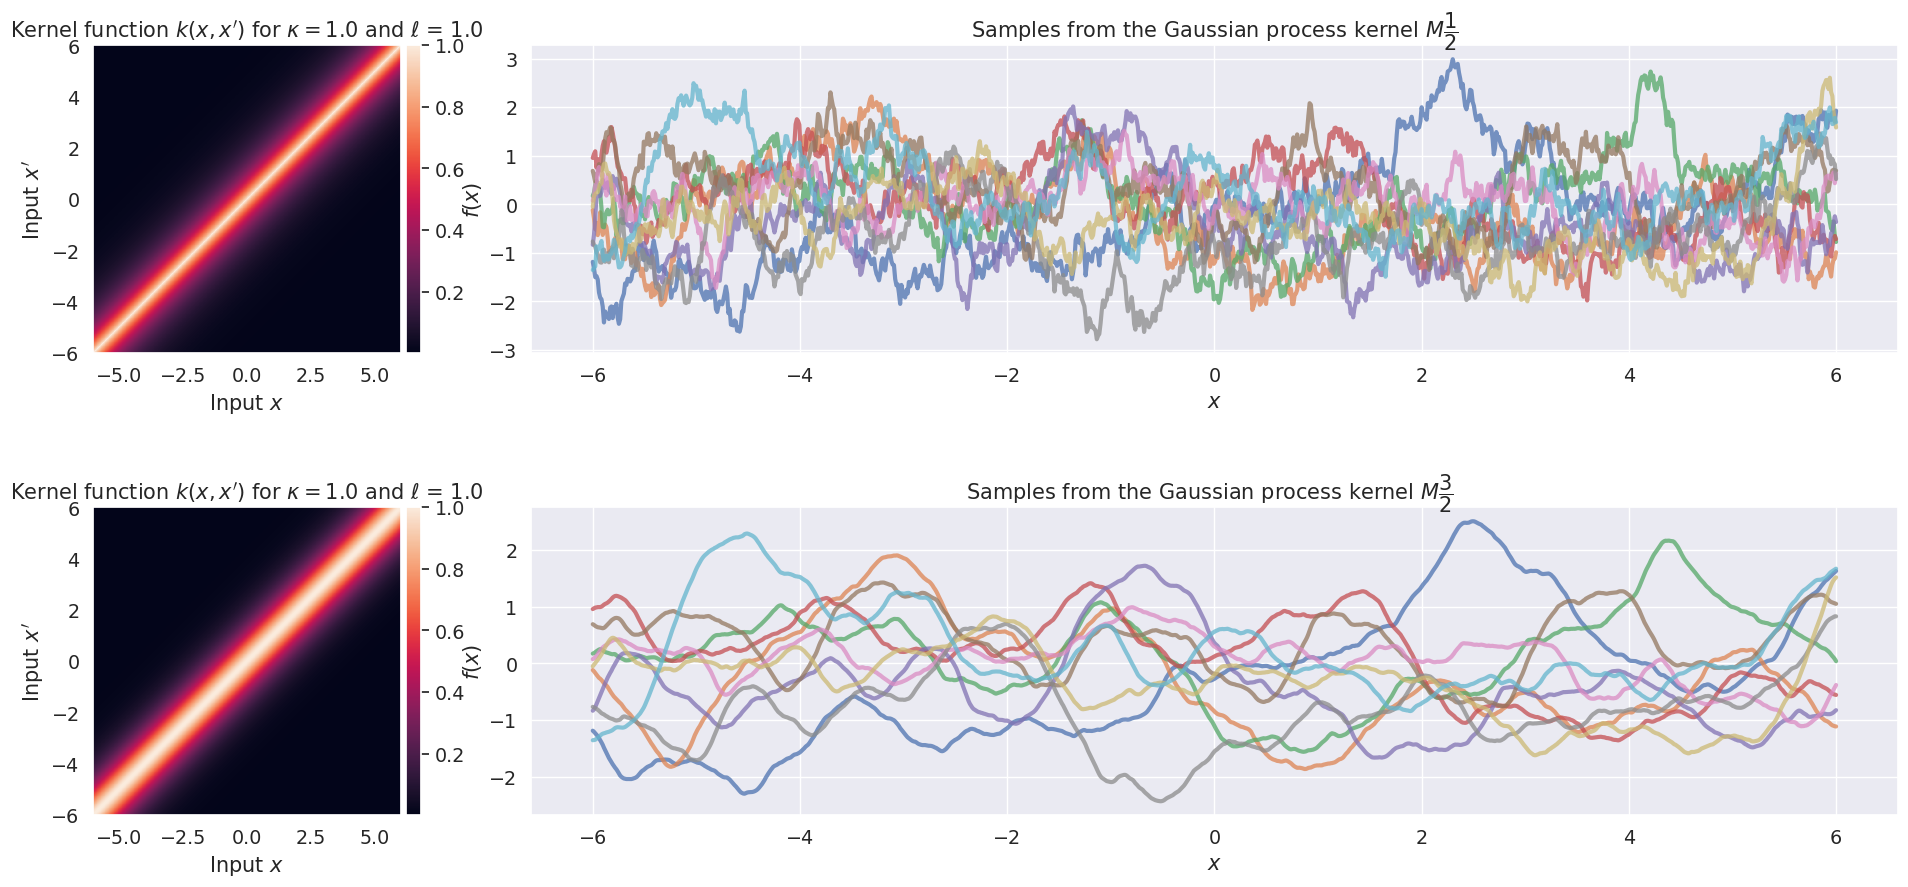

In [69]:
# create an Nx1 vector of equidistant points in [-6, 6]
N = 1000
X = jnp.linspace(-6, 6, N)[:, None]

# hyperparameters
kappa = 1.
scale = 1.

# number of samples to be plotted
num_samples = 10

# specify random seed
seed = 1
key = random.PRNGKey(1)

# instantiate kernel object and construct kernel
kernel_one_half = StationaryIsotropicKernel(matern12, kappa, scale)
kernel_three_half = StationaryIsotropicKernel(matern32, kappa, scale)
K_one_half = kernel_one_half.contruct_kernel(X, X)
K_three_half = kernel_three_half.contruct_kernel(X, X)

# plot
fig, ax = plt.subplots(2, 2, figsize=(30, 10))

m = jnp.zeros(len(X))
im = ax[0][0].pcolormesh(X.flatten(), X.flatten(), K_one_half, shading='auto')
ax[0][0].set(xlabel='Input $x$', ylabel="Input $x'$", title=f"Kernel function $k(x, x')$ for $\\kappa = {kappa:2.1f}$ and $\\ell$ = {scale:2.1f}")
ax[0][0].grid(False)
ax[0][0].set_aspect('equal')
add_colorbar(im, fig, ax[0][0])

f_samples = generate_samples(key, m, K_one_half, num_samples=num_samples, jitter=1e-8)
ax[0][1].plot(X, f_samples, alpha=0.75, linewidth=3);
ax[0][1].grid(True)
ax[0][1].set(xlabel='$x$', ylabel='$f(x)$', title=r'Samples from the Gaussian process kernel $M\dfrac{1}{2}$');


# add vertical space between the two rows
fig.subplots_adjust(hspace=0.5)
# add vertical space between the two columns
fig.subplots_adjust(wspace=-.3)

im = ax[1][0].pcolormesh(X.flatten(), X.flatten(), K_three_half, shading='auto')
ax[1][0].set(xlabel='Input $x$', ylabel="Input $x'$", title=f"Kernel function $k(x, x')$ for $\\kappa = {kappa:2.1f}$ and $\\ell$ = {scale:2.1f}")
ax[1][0].grid(False)
ax[1][0].set_aspect('equal')
add_colorbar(im, fig, ax[1][0])

f_samples = generate_samples(key, m, K_three_half, num_samples=num_samples, jitter=1e-8)
ax[1][1].plot(X, f_samples, alpha=0.75, linewidth=3);
ax[1][1].grid(True)
ax[1][1].set(xlabel='$x$', ylabel='$f(x)$', title=r'Samples from the Gaussian process kernel $M\dfrac{3}{2}$  ');


A simple way to understand and compare the three covariance functions (squared exponential, Matérn12, and Matérn32) is to study how they decay as a function of $||\tau|| = ||\mathbf{x}_n - \mathbf{x}_m||$:

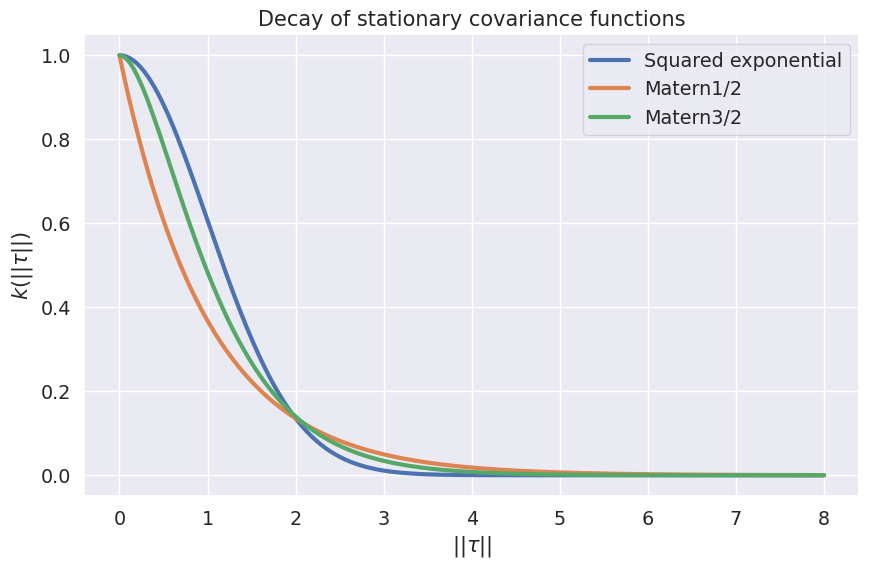

In [70]:
tau = jnp.linspace(0, 8, 200)

kappa = 1
scale = 1

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(tau, squared_exponential(tau, kappa=kappa, lengthscale=scale), linewidth=3, label='Squared exponential')
ax.plot(tau, matern12(tau, kappa=kappa, lengthscale=scale), linewidth=3, label='Matern1/2')
ax.plot(tau, matern32(tau, kappa=kappa, lengthscale=scale), linewidth=3, label='Matern3/2')
ax.set(xlabel='$||\\tau||$', ylabel='$k(||\\tau||)$', title='Decay of stationary covariance functions')
ax.legend()

Suppose the distance between two input points $\mathbf{x}_n$ and $\mathbf{x}_m$ is  $d\cdot \ell$, i.e. $\|\tau\| = \|\mathbf{x}_n - \mathbf{x}_m\| = d\cdot\ell$.

**Task 2.6**: Using the squared exponential covariance function and assume $\kappa = 1$, what is the covariance between the function values $f(\mathbf{x}_n)$ and $f(\mathbf{x}_m)$ for $d = 0, 1, 2, 3, 4, 5$?

*Hints: Use eq. (5)*

$$\begin{align*}
    k_{\text{SE}}(\mathbf{x}_n, \mathbf{x}_m) = k(||\tau||) =  \kappa^2 \exp\left(-\frac{\|\tau\|^2_ 2}{2\ell^2}\right), \tag{5}
\end{align*}$$






In [71]:
for i in jnp.arange(6):
    print(f"K = {jnp.exp(- i ** 2 / 2 ):.2f} for d = {i}")

K = 1.00 for d = 0
K = 0.61 for d = 1
K = 0.14 for d = 2
K = 0.01 for d = 3
K = 0.00 for d = 4
K = 0.00 for d = 5


**Task 2.7**: What can we say about the statistical relationship between the function values $f(\mathbf{x}_n)$ and $f(\mathbf{x}_m)$ when $d \gg 4$?  What can we say in general about the function values $f(\mathbf{x}_n)$ and $f(\mathbf{x}_m)$ for points $\mathbf{x}_n$ and $\mathbf{x}_m$ that separated by more than a few lengthscales?

**Solution**

For $d \gg 4$, the covariance between the function values $f(\mathbf{x}_n)$ and $f(\mathbf{x}_m)$ is smaller than $\exp(-8) \approx 10^{-3}$. Hence, the function values are effectively *uncorrelated*. Moreover, jointly Gaussian random variables have the special property that if uncorrelated variables are also **statistically independent**. Hence, function values for input points separated by more than a few lengthscales are effective statistically independent a priori for the squared exponential kernel. 

**End of solution**


# Part 3:  Non-linear regression using Gaussian processes

In this part, we will study how Gaussian processes can be used for non-linear regression. First, we will study a simple toy data set $\mathcal{D} = \left\lbrace (x_n, y_n) \right\rbrace_{n=1}^N$ for $N = 50$:



50


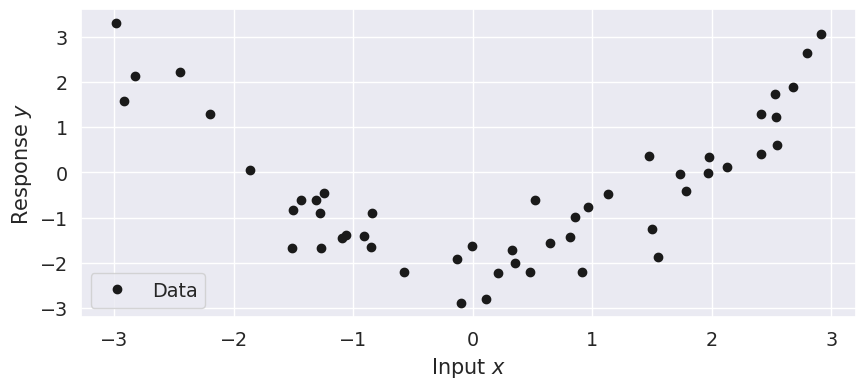

In [72]:
# load data
data = jnp.load('./data_exercise5.npz')
N = data['N']
print(N)
Xtrain, ytrain = data['X'], data['y']  # shape Xtrain (N = 50, 1), shape ytrain (N = 50, 1)


# for predictions
Xstar = jnp.linspace(-3, 9, 100)[:, None]   # shape Xstar (100, 1)

# function for plotting
def plot_data(ax):
    ax.plot(Xtrain, ytrain, 'k.', markersize=12, label='Data')
    ax.grid(True)
    ax.set_xlabel('Input $x$')
    ax.set_ylabel('Response $y$')
    ax.legend()

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plot_data(ax)


We will adopt the following model

$$
\begin{align*}
y_n = f(\mathbf{x}_n) + e_n,
\end{align*}
$$

where $f(\mathbf{x})$ is assumed to be a Gaussian process. Assuming the noise $e_n$ is i.i.d. and Gaussian, the joint model for the training data becomes:

\begin{align*}
p(\mathbf{y}, \mathbf{f}) = \mathcal{N}\left(\mathbf{y}|\mathbf{f}, \sigma^2\mathbf{I}\right)\mathcal{N}\left(\mathbf{f} | \mathbf{0}, \mathbf{K}\right)
\end{align*}

where $\mathbf{K}_{nm} = k(\mathbf{x}_n, \mathbf{x}_m)$ is the covariance matrix. 
We will also use the squared exponential and Matérn covariance functions in this part. Thus, this model (when using these covariance functions) has three hyperparameters in total: $\mathbf{\theta} = \left\lbrace \sigma, \kappa, \ell\right\rbrace$, where 

- $\sigma > 0$ is the standard deviation of the noise, 

- $\kappa > 0$ is the magnitude of the kernel,

- $\ell > 0$ is the lengthscale of the kernel. 

We will use $\mathbf{\theta}_K = \left\lbrace \kappa, \ell\ \right\rbrace$ to denote the hyperparameters of the kernel $K$ and $\mathbf{\theta}$ to denote all hyperparameters of the model.



Below you are given an incomplete implementation of a class for Gaussian process regression. The function called **compute_posterior** is supposed to the posterior mean and covariance matrix of the function values $f(\mathbf{x}^*)$ for input $\mathbf{x}^*$ conditioned on the training data $\mathbf{y}$.
The class contains a template for the following functions:

- `predict_f`: computes the posterior distribution of the function value $f(\mathbf{x}^*)$ for a new input, $\mathbf{x}^*$, i.e. $p(f^*|\mathbf{y}) = \mathcal{N}(f^*|\mu_{f^*}, \Sigma_{f^*})$
- `predict_y`: computes the posterior predictive distribution of for a new observation at new input, $\mathbf{x}^*$, i.e. $p(y^*|\mathbf{y}) = \mathcal{N}(y^*|\mu_{y^*}, \Sigma_{y^*})$
- `posterior_samples`: generates samples from the posterior distribution of $f^*$ for a set of inputs, i.e. $\mathbf{f}^* \sim p(f^*|\mathbf{y})$
- `log_marginal_likelihood`: evaluate the log marginal likelihood for a given set if hyperparameters $\theta$

In this part, we will focus on the first three and then come back to the marginal likelihood later.

> **Task 3.1**: Complete the implementation of the function `predict_f` below.

*Hints*:
- *Look at eq. (17.34), (17.35) and (17.36) in Murphy1*
- *For computing matrix-vector prodcuts of the form $\mathbf{A}^{-1} \mathbf{x}$, `np.linalg.solve(A, x)` is numerically much more stable than `np.linalg.inv(A)@x`*.
- *If you prefer, you can move the class to a separate python module and import it to the notebook if you prefer not the scroll up and down during as you make it through the notebook*.




> **Task 3.2**: Complete the implementation of the function `predict_y` below.

*Hints: Use the function `predict_f` you implemented in the previous task to do most of the work*

> **Task 3.3**: Complete the implementation of the function `posterior_samples` below.

*Hints: The implementation of this should be easy and make heavy use of functions you already implemented*



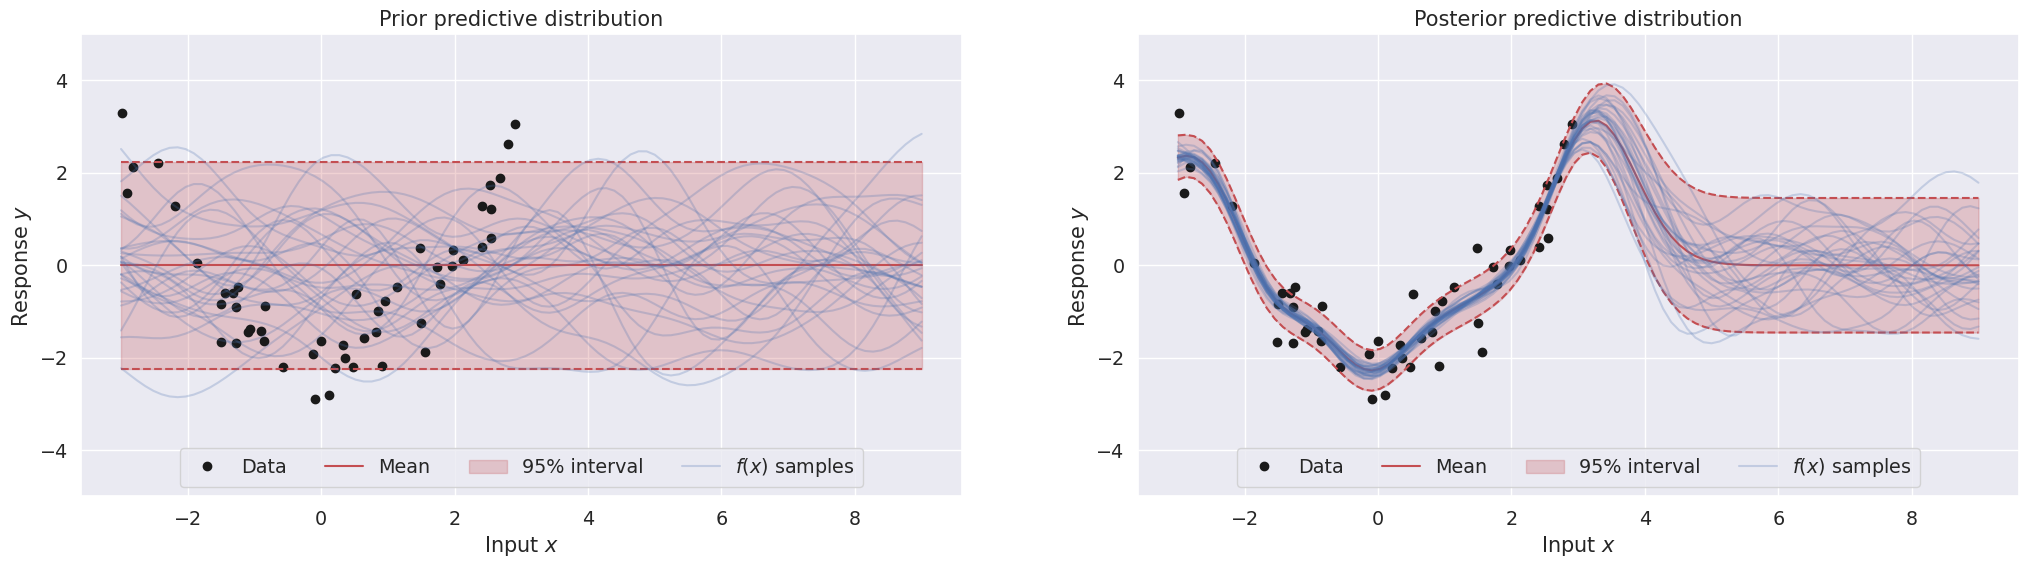

In [73]:
def plot_with_uncertainty(ax, Xp, gp, color='r', color_samples='b', title="", num_samples=0, seed=0):
    
    mu, Sigma = gp.predict_y(Xp)
    mean = mu.ravel()
    std = jnp.sqrt(jnp.diag(Sigma))

    # random seed
    key = random.PRNGKey(seed)

    # plot distribution
    ax.plot(Xp, mean, color=color, label='Mean')
    ax.plot(Xp, mean + 2*std, color=color, linestyle='--')
    ax.plot(Xp, mean - 2*std, color=color, linestyle='--')
    ax.fill_between(Xp.ravel(), mean - 2*std, mean + 2*std, color=color, alpha=0.25, label='95% interval')
    
    # generate samples
    if num_samples > 0:
        fs = gp.posterior_samples(key, Xstar, num_samples)
        ax.plot(Xp, fs[:,0], color=color_samples, alpha=.25, label="$f(x)$ samples")
        ax.plot(Xp, fs[:, 1:], color=color_samples, alpha=.25)
    
    ax.set_title(title)
    



class GaussianProcessRegression(object):

    def __init__(self, X, y, kernel, kappa=1., lengthscale=1., sigma=1/2, jitter=1e-8):
        """  
        Arguments:
            X                -- NxD input points
            y                -- Nx1 observed values 
            kernel           -- must be instance of the StationaryIsotropicKernel class
            jitter           -- non-negative scaler
            kappa            -- magnitude (positive scalar)
            lengthscale      -- characteristic lengthscale (positive scalar)
            sigma            -- noise std. dev. (positive scalar)
        """
        self.X = X
        self.y = y
        self.N = len(X)
        self.kernel = kernel
        self.jitter = jitter
        self.set_hyperparameters(kappa, lengthscale, sigma)
        self.check_dimensions()

    def check_dimensions(self):
        assert self.X.ndim == 2, f"The variable X must be of shape (N, D), however, the current shape is: {self.X.shape}"
        N, D = self.X.shape

        assert self.y.ndim == 2, f"The varabiel y must be of shape (N, 1), however. the current shape is: {self.y.shape}"
        assert self.y.shape == (N, 1), f"The varabiel y must be of shape (N, 1), however. the current shape is: {self.y.shape}"
        

    def set_hyperparameters(self, kappa, lengthscale, sigma):
        self.kappa = kappa
        self.lengthscale = lengthscale
        self.sigma = sigma

    def posterior_samples(self, key, Xstar, num_samples):
        """
            generate samples from the posterior p(f^*|y, x^*) for each of the inputs in Xstar

            Arguments:
                key              -- jax random key for controlling the random number generator
                Xstar            -- PxD prediction points
        
            returns:
                f_samples        -- numpy array of (P, num_samples) containing num_samples for each of the P inputs in Xstar
        """
        ##############################################
        # Your solution goes here
        ##############################################
        
        mu, Sigma = self.predict_f(Xstar)
        f_samples = generate_samples(key, mu.ravel(), Sigma, num_samples)
        
        ##############################################
        # End of solution
        ##############################################

        assert (f_samples.shape == (len(Xstar), num_samples)), f"The shape of the posterior mu seems wrong. Expected ({len(Xstar)}, {num_samples}), but actual shape was {f_samples.shape}. Please check implementation"
        return f_samples
        
    def predict_y(self, Xstar):
        """ returns the posterior distribution of y^* evaluated at each of the points in x^* conditioned on (X, y)
        
        Arguments:
        Xstar            -- PxD prediction points
        
        returns:
        mu               -- Px1 mean vector
        Sigma            -- PxP covariance matrix
        """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare relevant matrices
        mu, Sigma = self.predict_f(Xstar)
        Sigma = Sigma + self.sigma**2 * jnp.identity(len(mu))
        
        ##############################################
        # End of solution
        ##############################################

        return mu, Sigma

    def predict_f(self, Xstar):
        """ returns the posterior distribution of f^* evaluated at each of the points in x^* conditioned on (X, y)
        
        Arguments:
        Xstar            -- PxD prediction points
        
        returns:
        mu               -- Px1 mean vector
        Sigma            -- PxP covariance matrix
        """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare relevant matrices
        k = self.kernel.contruct_kernel(Xstar, self.X, self.kappa, self.lengthscale, jitter=self.jitter)
        K = self.kernel.contruct_kernel(self.X, self.X, self.kappa, self.lengthscale, jitter=self.jitter)
        Kstar = self.kernel.contruct_kernel(Xstar, Xstar, self.kappa, self.lengthscale, jitter=self.jitter)
        
        # Compute C matrix
        C = K + self.sigma**2*jnp.identity(len(self.X)) 

        # computer mean and Sigma
        mu = jnp.dot(k, jnp.linalg.solve(C, self.y))
        Sigma = Kstar - jnp.dot(k, jnp.linalg.solve(C, k.T))
        
        ##############################################
        # End of solution
        ##############################################

        # sanity check for dimensions
        assert (mu.shape == (len(Xstar), 1)), f"The shape of the posterior mu seems wrong. Expected ({len(Xstar)}, 1), but actual shape was {mu.shape}. Please check implementation"
        assert (Sigma.shape == (len(Xstar), len(Xstar))), f"The shape of the posterior Sigma seems wrong. Expected ({len(Xstar)}, {len(Xstar)}), but actual shape was {Sigma.shape}. Please check implementation"

        return mu, Sigma
    
    
    def prior_predictive_f_star(self, Xstar):
        """
        Computes the prior predictive distribution for f^* at the test points Xstar.

        Arguments:
            Xstar -- PxD array of prediction points

        Returns:
            mu0   -- Px1 mean vector (all zeros, since prior mean is zero)
            Sigma0-- PxP covariance matrix (prior covariance for f^*)

        Mathematical details:
            - Prior mean:   mu0 = 0
            - Prior covariance: Sigma0 = K(Xstar, Xstar)
            - Shapes: mu0.shape = (P, 1), Sigma0.shape = (P, P)
        """
        K_star = self.kernel.contruct_kernel(Xstar, Xstar, self.kappa, self.lengthscale)
        mu0 = jnp.zeros((len(Xstar), 1))
        Sigma0 = K_star 
        return mu0, Sigma0

    def prior_predictive_y_star(self, Xstar):
        """
        Computes the prior predictive distribution for y^* at the test points Xstar,
        including observation noise.

        Arguments:
            Xstar -- PxD array of prediction points

        Returns:
            mu0   -- Px1 mean vector (all zeros, since prior mean is zero)
            Sigma0-- PxP covariance matrix (prior covariance for y^*)

        Mathematical details:
            - Prior mean:   mu0 = 0
            - Prior covariance: Sigma0 = K(Xstar, Xstar) + sigma^2 * I
            - Shapes: mu0.shape = (P, 1), Sigma0.shape = (P, P)
            - Equation: y^* ~ N(0, K(Xstar, Xstar) + sigma^2 * I)
        """
        K_star = self.kernel.contruct_kernel(Xstar, Xstar, self.kappa, self.lengthscale)
        mu0 = jnp.zeros((len(Xstar), 1))
        Sigma0 = K_star + self.sigma**2 * jnp.identity(len(Xstar))
        return mu0, Sigma0
    
    
    def log_marginal_likelihood(self, kappa, lengthscale, sigma):
        """ 
            evaluate the log marginal likelihood p(y) given the hyperparaemters 

            Arguments:
            kappa       -- positive scalar 
            lengthscale -- positive scalar
            sigma       -- positive scalar
            """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare kernels
        K = self.kernel.contruct_kernel(self.X, self.X, kappa, lengthscale)
        C = K + sigma**2*jnp.identity(self.N)

        # compute Cholesky decomposition
        L = jnp.linalg.cholesky(C)
        v = jnp.linalg.solve(L, self.y)

        # compute log marginal likelihood
        logdet_term = jnp.sum(jnp.log(jnp.diag(L)))
        quad_term =  0.5*jnp.sum(v**2)
        const_term = -0.5*self.N*jnp.log(2*jnp.pi)

        return const_term - logdet_term - quad_term
        
        ##############################################
        # End of solution
        ##############################################
        
# instantiate kernel
kernel = StationaryIsotropicKernel(kernel_fun=squared_exponential)

# instantiate GP without data (hence, posterior=prior) and with data
gp_prior = GaussianProcessRegression(jnp.zeros((0, 1)), jnp.zeros((0, 1)), kernel)
gp_post = GaussianProcessRegression(Xtrain, ytrain, kernel, 0.7, 0.5 * jnp.sqrt(2), 1/5)

# plot
fig, ax = plt.subplots(1, 2, figsize=(25, 6))
plot_data(ax[0])
plot_with_uncertainty(ax[0], Xstar, gp_prior, title='Prior predictive distribution', num_samples=30)
ax[0].legend(loc='lower center', ncol=4)
ax[0].set_ylim((-5, 5))

plot_data(ax[1])
plot_with_uncertainty(ax[1], Xstar, gp_post, title='Posterior predictive distribution', num_samples=30)
ax[1].legend(loc='lower center', ncol=4)
ax[1].set_ylim((-5, 5));

In [74]:
gp_post.prior_predictive_y_star(jnp.array([0]))



(Array([[0.]], dtype=float64), Array([[0.53000001]], dtype=float64))

In [75]:
gp_post.predict_y(jnp.array([227]))

(Array([[0.]], dtype=float64), Array([[0.53000001]], dtype=float64))

If the code has been implemented correct, then the left figure above shows 30 samples from the prior predictive distribution along with the mean and 95% interval from the prior predictive distribution, whereas the right figure shows the same quantities for the posterior predictive distribution.

> **Task 3.4**: Inspect the plots above. How does the prior and posterior predictive differ in: a) regions close to the data points? b) in regions far from the data point? [**Discussion question**]


### a) Regions close to observed data

| Aspect                               | Prior predictive (left panel)                                                                                            | Posterior predictive (right panel)                                                                                                                                                                                                                            |
| ------------------------------------ | ------------------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Mean curve**                       | Zero everywhere (flat red line) because we assumed a zero-mean GP prior and the prior does not “know” the data location. | Follows the black points smoothly: the red line bends to pass through the cloud of observations.  This is the data-conditioned posterior mean $\mu_*(x)=k_{xX}C^{-1}y$.                                                                                      |
| **Uncertainty band (95 % interval)** | Wide and constant: $\pm 2\kappa$ (here ≈ ±2) across the whole x-axis, reflecting pure prior variance.                    | Collapses tightly around the data.  Mathematically, the posterior covariance $\Sigma_*(x,x')=K_*(x,x')-k_{xX}C^{-1}k_{Xx'}$ **subtracts** the second term; when $x$ is near training inputs $k_{xX}$ is large → big subtraction → small posterior variance. |
| **Sample paths $f(x)$**              | Look like random spaghetti with no apparent structure.                                                                   | Stick close to the mean where data are dense, showing only small vertical wiggles inside the narrow band.                                                                                                                                                     |


**Why?**  
Near a training point $ x_n $, the kernel row $ k_{xX} $ is almost a one-hot vector: its value at $ x_n $ is $ \kappa^2 $, and it decays quickly away. Consequently:

$$
\operatorname{Var}[f(x) \mid y] = \kappa^2 - k_{xX} C^{-1} k_{Xx}
$$

This drops sharply, and the predictive mean essentially interpolates the noisy observation.

### ⚙️ Setup (shared for both cases)

- **Squared Exponential kernel**:  
  $$
  k(x, x') = \kappa^2 \exp\left( -\frac{(x - x')^2}{2\ell^2} \right)
  $$
- **Hyperparameters**:  
  $\kappa^2 = 1$, $\ell = 1$, $\sigma^2 = 0.1$

- **Training inputs**:  
  $X = [0.0, 1.0]$

- **Covariance matrix with noise**:  
  $$
  C = 
  \begin{bmatrix}
  1.1 & 0.6065 \\
  0.6065 & 1.1
  \end{bmatrix}
  $$

---

### 🟢 Case 1: Test point **near** training input

- Test input: $x_* = 0.05$ (close to $x = 0$)

- $k(x_*, x_*) = 1$
- $k_{xX} = [0.99875, 0.6369]$

Posterior variance:
$$
\Sigma(x_*, x_*) = 1 - k_{xX} C^{-1} k_{Xx}
$$

Using an approximate value:
$$
k_{xX} C^{-1} k_{Xx} \approx 0.919
$$

So:
$$
\Sigma(x_*, x_*) \approx 1 - 0.919 = \boxed{0.081}
$$

✅ **Conclusion**: Close to data $\Rightarrow$ large kernel values $\Rightarrow$ big subtraction $\Rightarrow$ low variance

---

### 🔴 Case 2: Test point **far** from training inputs

- Test input: $x_* = 5.0$ (far from any $x_n$)

- $k(x_*, x_*) = 1$
- $k_{xX} = [\exp(-12.5), \exp(-8)] \approx [3.7 \cdot 10^{-6}, 3.4 \cdot 10^{-4}] \approx 0$

Then:
$$
k_{xX} C^{-1} k_{Xx} \approx 0
$$

So:
$$
\Sigma(x_*, x_*) \approx 1 - 0 = \boxed{1}
$$

✅ **Conclusion**: Far from data $\Rightarrow$ weak correlation $\Rightarrow$ no subtraction $\Rightarrow$ prior variance

---

### ✏️ Summary Table

| Location of $x_*$ | $k_{xX}$       | $\Sigma(x_*, x_*)$ | Interpretation                          |
|-------------------|----------------|---------------------|------------------------------------------|
| Near (0.05)       | Large          | $\approx 0.081$     | Model is confident, interpolates data   |
| Far (5.0)         | Near zero      | $\approx 1.0$       | Model falls back to prior uncertainty    |


---

### b) Regions far from any data

| **Aspect**        | **Prior predictive**                                            | **Posterior predictive**                                                                 |
|-------------------|-----------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| **Mean curve**     | Still zero.                                                     | Reverts gradually toward zero—the same as the prior mean—because kernel correlations $ k_{xX} $ go to zero when $ x $ is many length-scales away from all data. |
| **Uncertainty band** | Stays at the prior height everywhere.                            | Expands back out to match the prior variance; the subtraction term $ k_{xX} C^{-1} k_{Xx} \to 0 $, so $ \operatorname{Var}[f(x)] $ returns to $ \kappa^2 $.     |
| **Sample paths**   | Same random spaghetti.                                          | Once outside the data range they again look like unconstrained GP draws because the model has “forgotten” the data.              |

---

**Why?**  
The squared-exponential kernel is stationary and decays rapidly:

$$
k(r) = \kappa^2 \exp\left( -\frac{r^2}{2\ell^2} \right)
$$

If $ r \gg \ell $, then $ k(r) \approx 0 $, so test points far away are almost independent of the training set.  
The posterior therefore defaults back to the prior in both **mean** and **covariance**.

---

### Take-away intuition

- **Near data**: strong correlation $ \Rightarrow $ model is confident and closely tracks observations.  
- **Far from data**: weak correlation $ \Rightarrow $ the GP “falls back” to its prior beliefs—mean zero and variance $ \kappa^2 $.


> **Task 3.5**: Explain this behavior using the equations for the posterior mean and covariance of $f^*$ (and what you saw in part 2)? [**Discussion question**]

## 📌 Key Posterior Formulas

For a **zero-mean Gaussian Process** with additive i.i.d. noise $\sigma^2$:

$$
\mu_*(x) = k_{xX} C^{-1} y
$$

$$
\Sigma_*(x, x') = k(x, x') - k_{xX} C^{-1} k_{Xx'}
$$

where:
$$
C = K_{XX} + \sigma^2 I
$$

Here, $k_{xX}$ is the row vector:
$$
k_{xX} = [k(x, x_1), \dots, k(x, x_N)]
$$

---

## ⚙️ With the Squared-Exponential Kernel

$$
k(x, x_n) = \kappa^2 \exp\left( -\frac{(x - x_n)^2}{2\ell^2} \right)
$$

So, $k_{xX}$ is large **only when $x$ is within one to two length-scales $\ell$** of a training point.

---

## 🔴 Posterior Mean $\mu_*(x)$

- **Near data**:  
  $k_{xX}$ contains sizeable entries → the weighted sum $k_{xX} C^{-1} y$ reproduces the local pattern of $y$.  
  ▶️ In the right panel, the **red curve** hugs the observations.

- **Far from data**:  
  $k_{xX} \to 0$ exponentially ⇒ $\mu_*(x) \to 0$ (the prior mean).  
  ▶️ The **red curve** flattens to the horizontal baseline beyond approximately $3\ell$.

---

## 🔵 Posterior Variance (Diagonal of $\Sigma_*$)

$$
\operatorname{Var}[f(x) \mid y] = k(x, x) - k_{xX} C^{-1} k_{Xx}
$$

- **Near data**:  
  The first term is $\kappa^2$, but the subtraction term is nearly the same size because $k_{xX}$ is large.  
  ▶️ Big cancellation ⇒ small residual variance ⇒ the **blue band collapses** tightly around the mean.

- **Far from data**:  
  $k_{xX} \to 0$ ⇒ subtraction vanishes ⇒ variance returns to $\kappa^2$.  
  ▶️ The **blue band widens** back to the prior height (as shown in the raw kernel plot in part 2).

---

## 🤝 Intuitive Bridge to Part 2

- Part 2 showed that the SE kernel value decays from $1$ to $0.61$ at $1\ell$, and to $0.01$ by $3\ell$.

- These same values — entering into $k_{xX}$ — determine:
    - How strongly the data influences $\mu_*(x)$
    - How much uncertainty is removed in $\Sigma_*(x, x)$

| Distance from data | Behavior |
|--------------------|----------|
| Within $1\ell$     | Strong pull and strong variance reduction |
| Beyond $3\ell$     | Negligible influence, variance nearly unchanged |

This is exactly the transition observed between the center of the training cloud and the empty regions on either side in the posterior plot.


> **Task 3.6**: Visualize the prior covariance matrix for $f^*$ and posterior covariance for $f^*$ matrix side-by-side as images and comment on what you see



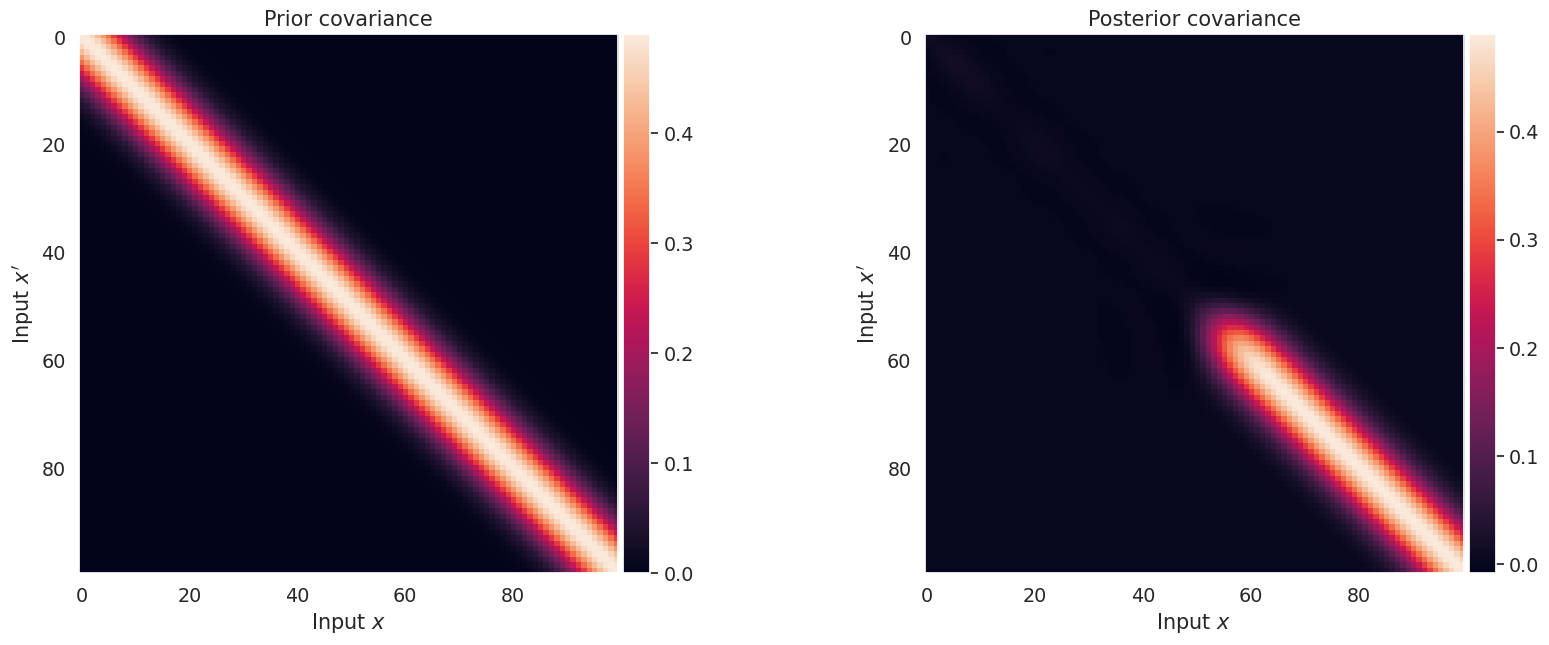

In [76]:
### compute mean and covariance of prior and posterior for f
mu_prior, Sigma_prior = gp_post.prior_predictive_f_star(Xstar)
mu_post, Sigma_post = gp_post.predict_f(Xstar)

# plot
fig, ax = plt.subplots(1, 2, figsize=(20, 7))
im = ax[0].imshow(Sigma_prior)
ax[0].grid(False)
ax[0].set(xlabel='Input $x$', ylabel="Input $x'$", title='Prior covariance')
add_colorbar(im, fig, ax[0])

im = ax[1].imshow(Sigma_post)
ax[1].grid(False)
ax[1].set(xlabel='Input $x$', ylabel="Input $x'$", title='Posterior covariance');
add_colorbar(im, fig, ax[1])

## 🎯 What the Two Heatmaps Are Showing

| **Panel** | **Matrix** | **Mathematical Form** | **What Each Pixel Means** |
|----------|------------|------------------------|-----------------------------|
| **Left** (prior) | $K_{**} = k(X_*, X_*)$ | $k(x, x') = \kappa^2 \exp\left( -\frac{(x - x')^2}{2\ell^2} \right)$ | The raw kernel evaluated on your prediction grid $X_* = [-3, \dots, 9]$. Bright diagonal $\approx \kappa^2$; off-diagonal entries fade with distance. |
| **Right** (posterior) | $\Sigma_* = K_* - k C^{-1} k^\top$ | $C = K_{XX} + \sigma^2 I$ | The same grid **after conditioning** on the training data. A low-variance “dent” appears wherever the grid overlaps training inputs. |

---

## 🧠 How to Read the Patterns

### Diagonal = Marginal Variance

- **Prior (left)**: Constant everywhere. Every test point has variance $\kappa^2$.
- **Posterior (right)**: Diagonal dips sharply at grid indices that match training points.  
  ▶️ The GP has learned the function there → **uncertainty collapses**.

### Off-Diagonal = Correlation

- **Prior**: Perfect SE stripes — depends only on $|x - x'|$.
- **Posterior**: Stripes are **erased** in regions with training data.  
  ▶️ Once $f(x)$ is known precisely, nearby points become less uncertain — **correlations shrink**.

### Far from the Data (Left & Right Edges)

- Both panels look identical far away.
- Why?  
  $k_{xX} \approx 0$ at large distances →  
  the subtraction term $k C^{-1} k^\top$ vanishes →  
  $\Sigma_* \to K_*$.
- ▶️ The model “forgets” the data for $x$ beyond roughly $3\ell$.

---

## 📌 One-Sentence Takeaway

Conditioning **subtracts the rank-$N$ term** $k C^{-1} k^\top$ from the prior kernel, **carving out a low-variance, low-correlation pocket** where observations exist, and **leaves the prior intact** everywhere else.


> **Task 3.7**: Change the values of kappa and scale and explain how it affects the prior and posterior. For example, what happens if you choose the lengthscale $\ell$ to be either 0.25, 1, or 5 while keeping $\kappa = 1$ and $\sigma = \frac12$? Do similar experiments with $\sigma$ and $\kappa$. [**Discussion question**]

## 🧪 Task 3.7 – Exploring Effects of Hyperparameters on Prior & Posterior

We consider a zero-mean GP with the **squared exponential (SE) kernel**:

$$
k(x, x') = \kappa^2 \exp\left(-\frac{(x - x')^2}{2\ell^2} \right)
$$

and observation noise variance $\sigma^2$.

We analyze the impact of changing:

- **Lengthscale** $\ell$
- **Signal variance** $\kappa^2$
- **Noise standard deviation** $\sigma$

---

### 🔍 1. Varying Lengthscale $\ell$ (with $\kappa = 1$, $\sigma = 0.5$)

#### Case A: $\ell = 0.25$ (very short lengthscale)

- **Prior**:
  - Rapid decay of kernel → each point is correlated only with its very close neighbors.
  - Prior samples are **very wiggly** (high-frequency variations).
- **Posterior**:
  - GP interpolates **locally** — only points within $\sim 0.25$ influence prediction.
  - Sharp drops in posterior variance near data.
  - Outside training regions, uncertainty rises quickly.

#### Case B: $\ell = 1$ (moderate lengthscale)

- **Prior**:
  - Moderate smoothness, broader correlations.
  - Samples are still flexible but less noisy.
- **Posterior**:
  - Predictions are **influenced by nearby regions** (≈ 1 unit away).
  - Variance dips span wider regions around training points.

#### Case C: $\ell = 5$ (long lengthscale)

- **Prior**:
  - Points are highly correlated even when far apart.
  - Prior samples are **very smooth** and slowly varying.
- **Posterior**:
  - Every data point affects predictions far away.
  - Posterior mean becomes a **global smoother**.
  - Variance is reduced even in distant regions.

---

### 📈 2. Varying Signal Variance $\kappa$ (with $\ell = 1$, $\sigma = 0.5$)

#### Case A: $\kappa = 0.5$

- **Prior**:
  - Low amplitude variation.
  - Prior samples are close to zero.
- **Posterior**:
  - Predictions are **less confident** — smaller overall variation.
  - Posterior variance is reduced, but from a smaller starting point.

#### Case B: $\kappa = 1$

- Standard case. Moderate prior variance, well-calibrated posterior.

#### Case C: $\kappa = 2$

- **Prior**:
  - High-amplitude functions.
  - Prior samples vary more widely.
- **Posterior**:
  - GP is **more confident** in its signal, allowing stronger responses to data.
  - Posterior variance also increases (more prior capacity to vary).

---

### 🌫️ 3. Varying Noise Level $\sigma$ (with $\ell = 1$, $\kappa = 1$)

#### Case A: $\sigma = 0.1$ (low noise)

- **Posterior**:
  - GP **trusts data strongly**.
  - Posterior interpolates the data closely.
  - Variance collapses almost to zero at training points.

#### Case B: $\sigma = 0.5$

- Balanced behavior — moderate smoothness and uncertainty.

#### Case C: $\sigma = 2.0$ (high noise)

- **Posterior**:
  - GP treats data as **unreliable**.
  - Posterior mean becomes flatter (closer to prior mean).
  - Posterior variance remains **high** — GP is uncertain.

---

## ✅ Summary Table

| Parameter | Increase → | Effect on Prior | Effect on Posterior |
|-----------|------------|------------------|----------------------|
| $\ell$    | Smoother kernel | Longer-range correlations | Wider influence of data |
| $\kappa$  | Taller kernel | Higher amplitude variation | Larger posterior variance |
| $\sigma$  | Noisier data | Doesn't affect prior | Posterior trusts data **less**, increases uncertainty |







> **Task 3.8**: Experiment with the two other kernerls, the Matérn $\frac12$ and the Matérn $\frac{3}{2}$. How does that affect the fits and the predictions? [**Discussion question**]


## 🔄 Task 4 – Swapping the Kernel: Matérn $\frac{1}{2}$ and Matérn $\frac{3}{2}$

---

### 🔹 Matérn $\frac{1}{2}$ (Exponential Kernel)

$$
k_{\nu = \frac{1}{2}}(r) = \kappa^2 \exp\left( -\frac{r}{\ell} \right)
$$

- **Mathematical difference**:
  - Exponent is **linear** in $r$ (not quadratic like SE).
  - **Short-range slope** is **steeper**, but **long-range decay** is **slower** than the Squared Exponential (SE).

- **Visuals & Behavior**:
  - **Prior samples**: look rough, with sharp **kinks**.
  - **Posterior mean**: can **track abrupt changes** more readily.
  - **Posterior variance**:
    - The **"dent"** around training points is **deeper**, but much **narrower**.
    - Why? Because $k_{xX}$ **drops off quickly**, within a single lengthscale $\ell$ (due to exponential decay in $r$).
  - **Uncertainty** increases **rapidly** outside the data cloud.

---

### 🔸 Matérn $\frac{3}{2}$

$$
k_{\nu = \frac{3}{2}}(r) = \kappa^2 \left( 1 + \frac{\sqrt{3} r}{\ell} \right) \exp\left( -\frac{\sqrt{3} r}{\ell} \right)
$$

- **Smoothness**:
  - GP sample paths are **once differentiable**.
  - Lies **between SE and Matérn $\frac{1}{2}$** in terms of smoothness and flexibility.

- **Visuals & Behavior**:
  - **Posterior mean**: smoother than Matérn $\frac{1}{2}$, but still **more flexible than SE**.
  - **Posterior variance**:
    - Variance dips around data, but the dip is **wider** than for Matérn $\frac{1}{2}$.
    - In extrapolation, credible bands are **slightly wider** than SE.
    - Why? Because the **exponential tail** of the kernel **preserves correlation** farther out.

---

### 🧠 Summary

| Property                      | Matérn $\frac{1}{2}$         | Matérn $\frac{3}{2}$         | Squared Exponential (SE)   |
|-------------------------------|-------------------------------|-------------------------------|-----------------------------|
| Kernel form                   | $\exp(-r/\ell)$              | $(1 + \sqrt{3}r/\ell)\exp(-\sqrt{3}r/\ell)$ | $\exp(-r^2 / 2\ell^2)$       |
| Smoothness of paths           | Not differentiable (rough)    | Once differentiable           | Infinitely differentiable   |
| Fits abrupt changes?          | ✅ Yes (very local)           | ✅ Moderate                   | ❌ No (oversmooths)          |
| Posterior variance shape      | Deep, narrow dent             | Moderate, wide dent           | Smooth, global dip          |
| Extrapolation uncertainty     | Increases quickly             | Moderate                      | Increases smoothly           |

---

✅ **Takeaway**:
- Use **Matérn $\frac{1}{2}$** for highly non-smooth functions or localized changes.
- Use **Matérn $\frac{3}{2}$** for moderately smooth functions and robustness.
- Use **SE** only when the target function is known to be very smooth.



# Part 4:  Hyperparameter optimization using the marginal likelihood

Before we can apply this model in practice, we will study how we can use the ***marginal likelihood*** to estimate the hyperparameters of the model. If we let $\mathbf{\theta} \in \mathbb{R}^K$ denote all of our hyperparameters, then the **evidence approximation** suggests that we can estimate $\mathbf{\theta}$ as follows

\begin{align*}
\hat{\mathbf{\theta}} = \arg\max\limits_{\mathbf{\theta}} \ln p(\mathbf{y}|\mathbf{\theta}),
\end{align*}

where $p(\mathbf{y}|\mathbf{\theta})$ is the marginal likelihood of the model (see eq. (17.52) in Murphy1).


> **Task 4.1**: Go back up to the implementation of `GaussianProcessRegression`-class and complete the implementation of the function `log_marginal_likelihood`

- *Hints: The expression for the marginal likelihood contains both determinants and matrix inverse, which can be numerically fragile and lead to underflow/overflow. Hence, you need to be careful with the numerical implementation. See the details in the slides for this week*

If your implementation is correct, then the code below implement an optimization routine for the marginal likelihood. Note that we re-parametrize the hyperparameters in the log-domain before optimizing to ensure that the hyperparameter remain positive. We rely and the package `autograd` for computing the gradients.

In [77]:
"""
Gaussian Process Regression (GPR) — end‑to‑end usage with hyperparameter optimization.

This script shows how to:
1) define a stationary isotropic kernel (e.g., squared‑exponential / RBF),
2) build a Gaussian Process regression model,
3) optimize its hyperparameters by maximizing the log marginal likelihood (LML),
4) make prior and posterior predictions, and
5) visualize the results.

-----------------------
Notation & Equations
-----------------------
Let training inputs be X ∈ ℝ^{n×d}, targets y ∈ ℝ^{n×1}, and test inputs X_* ∈ ℝ^{m×d}.
We use a stationary isotropic kernel k(·,· | κ, ℓ) with signal scale κ > 0 (signal
standard deviation) and lengthscale ℓ > 0. For the squared‑exponential (RBF) kernel:

    k_SE(x, x' | κ, ℓ) = κ^2 * exp(- ||x - x'||^2 / (2 ℓ^2)).

Observation noise is σ > 0 (noise standard deviation), so the training covariance is

    K_XX = K(X, X) + σ^2 I_n,   where K(X, X)[i,j] = k(x_i, x_j | κ, ℓ).

The log marginal likelihood (LML) is

    log p(y | X, θ) = -1/2 * yᵀ K_XX^{-1} y
                      -1/2 * log |K_XX|
                      -n/2 * log(2π),

with θ = (κ, ℓ, σ). We *minimize* the negative LML.

Predictive distribution for the latent function f at X_*:

    μ_* = K_{*X} K_XX^{-1} y,     Σ_* = K_{**} - K_{*X} K_XX^{-1} K_{X*},

where K_{*X} = K(X_*, X), K_{**} = K(X_*, X_*). If you need predictive distribution
for noisy observations y_*, add σ^2 I_m to Σ_*.

-----------------------
Shapes (this example)
-----------------------
- Xtrain: jnp.ndarray, shape (n, d)
- ytrain: jnp.ndarray, shape (n, 1)   # column vector (consistent with this class)
- Xstar:  jnp.ndarray, shape (m, d)
- μ_*, Σ_* from gp.predict_f(Xstar):
    μ_*: jnp.ndarray, shape (m, 1)
    Σ_*: jnp.ndarray, shape (m, m)

-----------------------
Assumed class interface
-----------------------
The code assumes the following (typical) methods exist:

- GaussianProcessRegression(X, y, kernel):
    Constructs a GPR model with training data (X, y) and a kernel object.

- GaussianProcessRegression.log_marginal_likelihood(kappa, scale, sigma) -> float:
    Returns the LML given hyperparameters (κ, ℓ, σ). Here 'scale' corresponds to the
    kernel lengthscale ℓ (sometimes called 'length' or 'ls').

- GaussianProcessRegression.set_hyperparameters(kappa, scale, sigma) -> None:
    Sets the model hyperparameters (κ, ℓ, σ). The model uses these for K_XX, K_{*X}, etc.

- GaussianProcessRegression.predict_f(Xstar) -> (mu, Sigma):
    Returns predictive mean and covariance for f at Xstar, with shapes (m,1) and (m,m).

- StationaryIsotropicKernel(kernel_fun=...):
    Wraps a scalar base kernel function into a stationary isotropic kernel parameterized
    by (κ, ℓ). For the squared‑exponential kernel, 'scale' is interpreted as ℓ.

-----------------------
Usage pattern (high‑level)
-----------------------
1) Define a kernel, then instantiate *two* GP objects:
   - a "prior" GP with empty training data (to sample/prior‑predict),
   - a "posterior" GP with (Xtrain, ytrain) (to posterior‑predict).
2) Optimize (κ, ℓ, σ) on the posterior GP by maximizing LML.
3) Set the optimized hyperparameters on both prior and posterior GPs.
4) Call predict_f(Xstar) on each GP to get μ_* and Σ_*.
5) Plot using helper functions (assumed available): plot_data and plot_with_uncertainty.

Notes:
- Hyperparameters are constrained to be positive by optimizing in log‑space and
  transforming with exp(·).
- Your implementation should add a small 'jitter' (e.g., 1e-6 on the diagonal of K)
  for numerical stability when inverting/Cholesky‑factorizing K_XX.
"""


# Imports below are shown for clarity; ensure these exist in your environment.
# from jax import value_and_grad
# from scipy.optimize import minimize
# import jax.numpy as jnp
# import matplotlib.pyplot as plt



def optimize_hyperparameters(gp, theta_init):
    """
    Optimize GP hyperparameters by (approximately) maximizing the log marginal likelihood (LML).

    The parameter vector is θ = (κ, ℓ, σ) = (kappa, scale, sigma). To enforce positivity,
    this routine optimizes in log‑space: φ = log θ, and maps back via θ = exp(φ).

    Parameters
    ----------
    gp : GaussianProcessRegression
        A GP model that exposes:
          - gp.log_marginal_likelihood(kappa, scale, sigma) -> float
            (returns the *log* marginal likelihood, not its negative).
        The method is evaluated on the model's *current training data*.
        Make sure `gp` was constructed with your (Xtrain, ytrain).

    theta_init : jnp.ndarray, shape (3,)
        Positive initial guess for (κ, ℓ, σ). Example: jnp.array([1.0, 1.0, 1.0]).
        Ordering is strictly (kappa, scale, sigma).

    Returns
    -------
    theta : jnp.ndarray, shape (3,)
        The optimized hyperparameters (κ̂, ℓ̂, σ̂) in *original* space (positive values).

    Optimization target
    -------------------
    We minimize the negative LML:
        objective(φ) = - log p(y | X, θ=exp(φ))
    where φ := log θ. Gradients (value_and_grad) are taken w.r.t. φ.

    Notes
    -----
    - This function assumes availability of `value_and_grad` (from JAX) and
      `minimize` (e.g., SciPy). Any gradient‑based optimizer that accepts a
      value‑and‑gradient callable is suitable.
    - If your y has shape (n,1), the LML implementation should internally treat it as
      a vector of length n (e.g., squeeze) or handle the shape consistently.
    - Check `res.success`; if False, consider re‑trying with different `theta_init`,
      bounds, or a different optimizer.

    Example
    -------
    >>> kernel = StationaryIsotropicKernel(kernel_fun=squared_exponential)
    >>> gp_post = GaussianProcessRegression(Xtrain, ytrain, kernel)
    >>> theta0 = jnp.array([1.0, 1.0, 1.0])  # (kappa, lengthscale, noise)
    >>> theta_hat = optimize_hyperparameters(gp_post, theta0)
    >>> gp_post.set_hyperparameters(*theta_hat)  # use (κ̂, ℓ̂, σ̂)
    """
    # define optimization objective as the negative log marginal likelihood (minimize)
    objective = lambda params: -gp.log_marginal_likelihood(
        jnp.exp(params[0]),  # kappa = exp(φ_0) > 0
        jnp.exp(params[1]),  # scale (lengthscale) = exp(φ_1) > 0
        jnp.exp(params[2])   # sigma (noise std)  = exp(φ_2) > 0
    )

    # optimize using gradients wrt the *log* parameters
    res = minimize(value_and_grad(objective), jnp.log(theta_init), jac=True)

    # check for success
    if not res.success:
        print('Warning: optimization failed!')

    # return results in original space θ = exp(φ)
    theta = jnp.exp(res.x)
    return theta


Let's run it on our toy dataset:

Estimated hyperparameters
	sigma: 0.59
	kappa: 2.92
	scale: 1.82


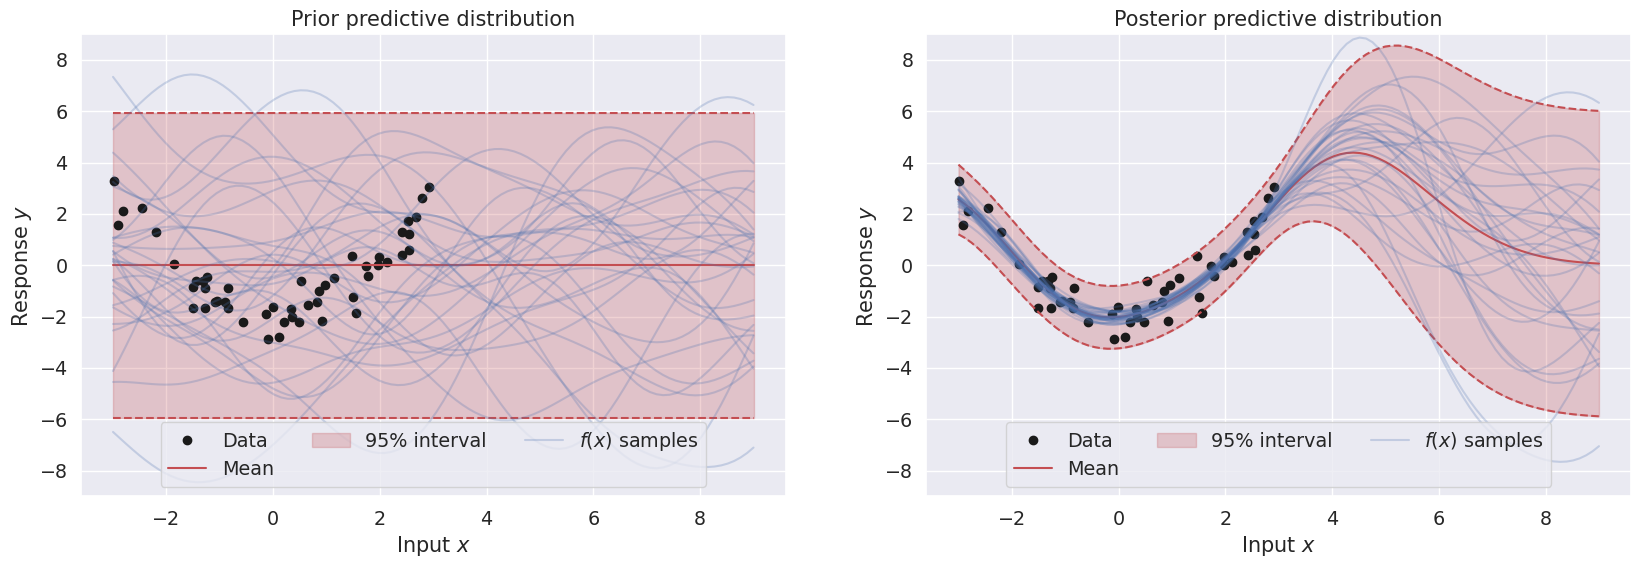

In [78]:
kernel = StationaryIsotropicKernel(kernel_fun=squared_exponential)
gp_prior = GaussianProcessRegression(jnp.zeros((0, 1)), jnp.zeros((0, 1)), kernel)
gp_post = GaussianProcessRegression(Xtrain, ytrain, kernel)

# optimize
theta_hat = optimize_hyperparameters(gp_post, theta_init=jnp.array([1,1,1]))

# extract individual hyperparameters
kappa_hat, scale_hat, sigma_hat = theta_hat

# print
print('Estimated hyperparameters')
print(f'\tsigma: {sigma_hat:3.2f}')
print(f'\tkappa: {kappa_hat:3.2f}')
print(f'\tscale: {scale_hat:3.2f}')


gp_prior = GaussianProcessRegression(jnp.zeros((0, 1)), jnp.zeros((0, 1)), kernel)
gp_post = GaussianProcessRegression(Xtrain, ytrain, kernel)
gp_prior.set_hyperparameters(kappa_hat, scale_hat, sigma_hat)
gp_post.set_hyperparameters(kappa_hat, scale_hat, sigma_hat)

mu_prior, Sigma_prior = gp_prior.predict_f(Xstar)
mu_post, Sigma_post = gp_post.predict_f(Xstar)
    
# plot
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
plot_data(ax[0])
plot_with_uncertainty(ax[0], Xstar, gp_prior, title='Prior predictive distribution', num_samples=30)
ax[0].legend(loc='lower center', ncol=3)
ax[0].set_ylim((-9, 9))
plot_data(ax[1])
plot_with_uncertainty(ax[1], Xstar, gp_post, title='Posterior predictive distribution', num_samples=30)
ax[1].legend(loc='lower center', ncol=3)
ax[1].set_ylim((-9, 9));

> **Task 4.2**: Comment on the quality of the fit. Does it seem reasonable? [**Discussion question**]


## ✅ Does the Posterior Look Sensible?

We analyze the behavior of a GP posterior inside and outside the data range.

---

### 📌 Inside the Data Range ($x \in [-3, 3]$)

| **Observation** | **Why This Happens** |
|-----------------|-----------------------|
| The red mean curve passes smoothly through the cloud of black points and captures the broad bowl-shaped trend. | The kernel length-scale $\hat{\ell}$ is large enough to **smooth across noise** but small enough to **follow curvature**. |
| The blue 95% band is **narrow where data are dense**; almost every point falls inside. | Posterior variance:  
$$
\Sigma_*(x) = k(x, x) - k_{xX} C^{-1} k_{Xx}
$$  
This subtracts a **large term** when $x$ is near training points → **uncertainty collapses**. |
| Sample paths **wiggle only slightly** around the mean. | The signal-to-noise ratio $\hat{\kappa} / \hat{\sigma}$ is **moderate**. Samples reflect **plausible latent functions**. |

---

### 📉 Outside the Data Range (e.g. $x > 3.5$)

| **Observation** | **Why This Happens** |
|-----------------|-----------------------|
| The mean reverts toward zero, then drifts upward slightly. | With no nearby data, $k_{xX} \approx 0$ ⇒ GP falls back to the **prior mean** (zero).  
But the **nearest training points around $x \approx 3$** still have a weak influence, causing a small **residual trend**. |
| The credible band **balloons to ±6–8 units**. | The subtraction term $k_{xX} C^{-1} k_{Xx}$ **vanishes**, so  
$$
\Sigma_*(x) \to k(x, x) = \hat{\kappa}^2
$$  
→ uncertainty grows back to the **prior variance**. |
| Samples **fan out dramatically** and look **much rougher**. | Without data constraints, they become **unconditional GP draws**, beyond the **influence radius** (≈ $3 \hat{\ell}$). |

---

### 🧠 Overall Judgement

- ✅ **Good fit in-range**:
  - Smooth posterior mean
  - Realistic credible intervals
  - No overfit or underfit near data

- ✅ **Plausible uncertainty out-of-range**:
  - Model admits uncertainty
  - Samples and variance reflect lack of knowledge

---

### 🔧 Possible Improvements (for sharper extrapolation)

- Use a **kernel with a larger effective length-scale** (e.g., Matérn-$\nu$ or composite kernels)
- Use a **non-zero mean function**, e.g., a **linear trend**
- Use a **heteroscedastic noise model** if the data's vertical spread varies with $x$

---

### ✅ Final Takeaway

> For a plain **Squared-Exponential GP** with automatically chosen $(\kappa, \ell, \sigma)$,  
> the posterior provides a **reasonable, principled fit**:
>
> - **Confident and accurate** within data  
> - **Honest and uncertain** outside the data



> **Task 4.3**: If we were to fit the three hyperparameters using 5-fold cross-validation and a grid search rather than using the marginal likelihood, how many times would we have to train the model? Assume we would 10 different values for each hyperparameter.

## 🧮 Cost of Grid Search vs Optimizing the Log Marginal Likelihood

Each full GP **fit** (i.e. Cholesky decomposition of the training covariance matrix) must be recomputed:

- **For every combination of hyperparameters**, and  
- **For every fold** in cross-validation.

---

### 🔢 Grid Search Setup

| Hyperparameter        | Values Tried |
|-----------------------|--------------|
| Signal variance $\kappa$ | 10           |
| Length-scale $\ell$      | 10           |
| Noise std. $\sigma$      | 10           |

- **Total grid points**:
  $$
  10 \times 10 \times 10 = 1{,}000
  $$

- **Number of CV folds**: 5

---

### 🚀 Total Number of Model Fits

Each grid point requires 5 fits (one per fold):

$$
1{,}000 \text{ grid points} \times 5 \text{ folds} = \boxed{5{,}000 \text{ model fits}}
$$

---

### ⚖️ Comparison

- **Brute-force 5-fold grid search**:  
  ⛔ **5,000 Cholesky decompositions**

- **Direct optimisation of log-marginal likelihood**:  
  ✅ Only **dozens** of Cholesky factorizations during gradient-based search.

---

### ✅ Takeaway

> **Optimising the marginal likelihood directly** is dramatically more efficient than grid search.  
> You avoid thousands of redundant model fits while still finding well-tuned hyperparameters.


# Part 5:  Analysing the bike sharing data set

In this section, your task is to fit a GP regression model (with squared exponential kernel) to a subset of the bike sharing dataset (Source: [https://ride.capitalbikeshare.com/system-data](https://ride.capitalbikeshare.com/system-data)). The dataset consists of the number of rented bikes in 2011.

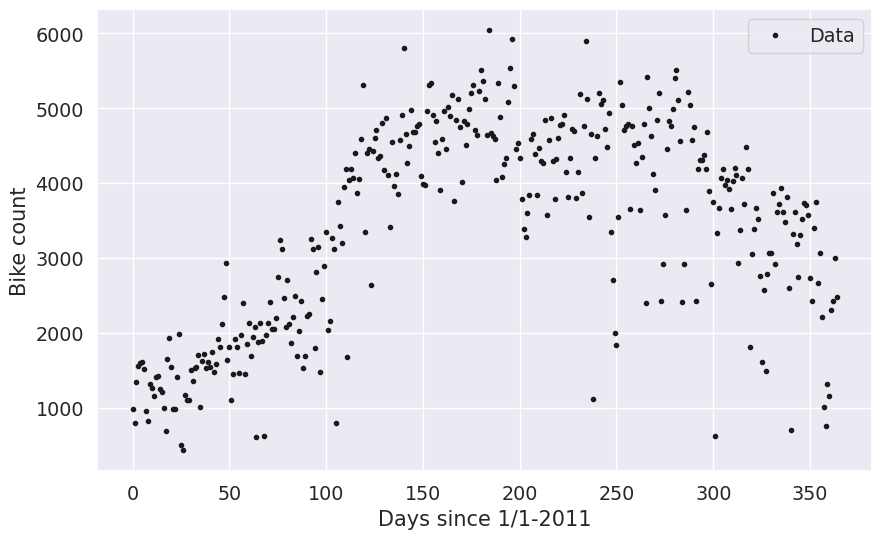

In [79]:
data = jnp.load('./data_exercise5b.npz')
day = data['day']
bike_count = data['bike_count']

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(day, bike_count, 'k.', label='Data')
ax.legend()
ax.set(xlabel='Days since 1/1-2011', ylabel='Bike count');


> **Task 5.1**: Log-transform the bike counts, remove the mean and scale to unit variance. Plot the preprocessed data set.


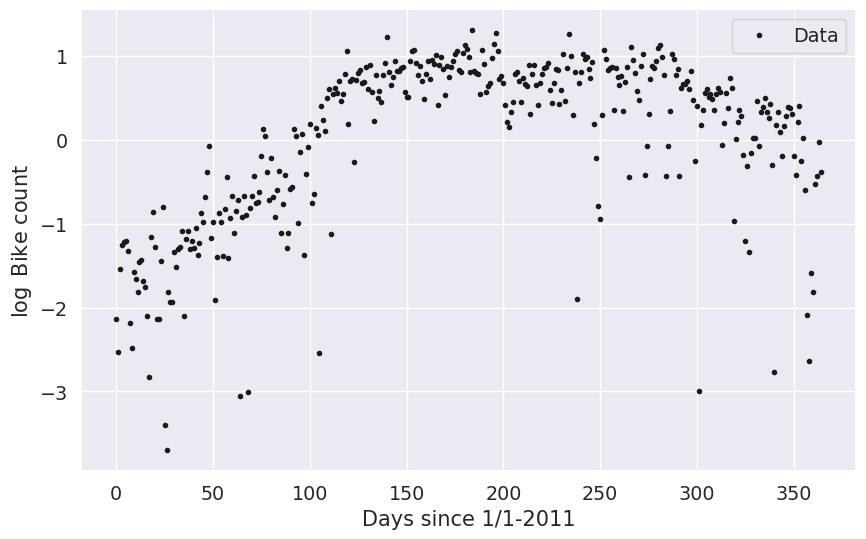

In [80]:
log_bike_count = jnp.log( bike_count )

y = log_bike_count

ym, ys = jnp.mean( y ), jnp.std( y )
y = ( y - ym ) / ys

X = day

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(X, y, 'k.', label='Data')
ax.legend()
ax.set(xlabel='Days since 1/1-2011', ylabel=r'$\log$ Bike count');

> **Task 5.2**: Estimate the hyperparameters of a Gaussian process regression model with a squared exponential kernel from the preprocessed data. Report the estimated values of each hyperparameter.


In [89]:
# prep gp
gp = GaussianProcessRegression(X, y, StationaryIsotropicKernel(squared_exponential))
gp_prior_bike = GaussianProcessRegression(jnp.zeros((0, 1)), jnp.zeros((0, 1)), StationaryIsotropicKernel(squared_exponential))

# optimize hyperparameters
theta_hat = optimize_hyperparameters(gp, theta_init=jnp.array([1, 1, 50.]))
kappa_hat, scale_hat, sigma_hat = theta_hat

# use new hyperparameters
gp.set_hyperparameters(kappa_hat, scale_hat, sigma_hat)
gp_prior_bike.set_hyperparameters(kappa_hat, scale_hat, sigma_hat)

print('Estimated hyperparameters')
print(f'\tsigma: {sigma_hat:3.2f}')
print(f'\tkappa: {kappa_hat:3.2f}')
print(f'\tscale: {scale_hat:3.2f}')
print('')
print(f'Log Z: {gp.log_marginal_likelihood(kappa_hat, scale_hat, sigma_hat):3.2f}')


Estimated hyperparameters
	sigma: 0.57
	kappa: 1.08
	scale: 78.63

Log Z: -324.85


> **Task 5.3**: Compute and visualize the predictive distribution for the interval $\text{day} \in \left\lbrace 0, 1, 2, \dots, 370 \right\rbrace$.

(0.0, 364.0)

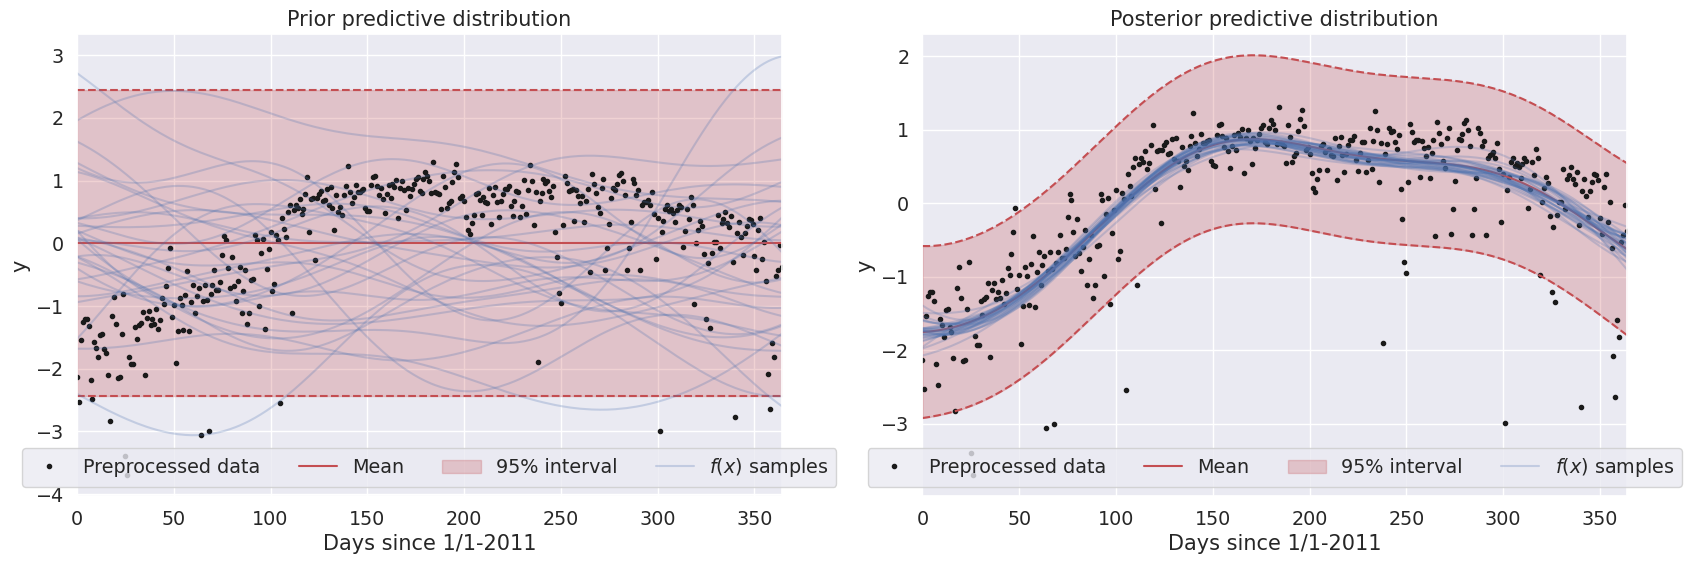

In [91]:
x_star_bike = jnp.arange(0, 370)[:, None]

#mu_prior_bike, Sigma_prior_bike = gp_prior_bike.predict_f(x_star_bike)
mu_post_bike, Sigma_post_bike = gp.predict_f(x_star_bike)
mu_prior_bike, Sigma_post_bike = gp.predict_f(x_star_bike)
# plot
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

ax[0].plot(X, y, 'k.', label='Preprocessed data')
plot_with_uncertainty(ax[0], x_star_bike, gp_prior_bike, title='Prior predictive distribution', num_samples=30)
ax[0].legend(loc='lower center', ncol=4)
ax[0].set(xlabel='Days since 1/1-2011', ylabel='y')
ax[0].set_xlim(X.min(), X.max())


ax[1].plot(X, y, 'k.', label='Preprocessed data')
plot_with_uncertainty(ax[1], x_star_bike, gp, title='Posterior predictive distribution', num_samples=30)
ax[1].legend(loc='lower center', ncol=4)
ax[1].set(xlabel='Days since 1/1-2011', ylabel='y')
ax[1].set_xlim(X.min(), X.max())

> **Task 5.4**: The observation model $p(y|f) = \mathcal{N}(y(x)|f(x), \sigma^2)$ assumes the additive noise is **isotropic** and **identically distributed** for all observations. Is that a reasonable assumption for this data set? **[Discussion question]**

## ✅ Does the Posterior Look Sensible?

We analyze the behavior of a GP posterior inside and outside the data range.

---

### 📌 Inside the Data Range ($x \in [-3, 3]$)

| **Observation** | **Why This Happens** |
|-----------------|-----------------------|
| The red mean curve passes smoothly through the cloud of black points and captures the broad bowl-shaped trend. | The kernel length-scale $\hat{\ell}$ is large enough to **smooth across noise** but small enough to **follow curvature**. |
| The blue 95% band is **narrow where data are dense**; almost every point falls inside. | Posterior variance:  
$$
\Sigma_*(x) = k(x, x) - k_{xX} C^{-1} k_{Xx}
$$  
This subtracts a **large term** when $x$ is near training points → **uncertainty collapses**. |
| Sample paths **wiggle only slightly** around the mean. | The signal-to-noise ratio $\hat{\kappa} / \hat{\sigma}$ is **moderate**. Samples reflect **plausible latent functions**. |

---

### 📉 Outside the Data Range (e.g. $x > 3.5$)

| **Observation** | **Why This Happens** |
|-----------------|-----------------------|
| The mean reverts toward zero, then drifts upward slightly. | With no nearby data, $k_{xX} \approx 0$ ⇒ GP falls back to the **prior mean** (zero).  
But the **nearest training points around $x \approx 3$** still have a weak influence, causing a small **residual trend**. |
| The credible band **balloons to ±6–8 units**. | The subtraction term $k_{xX} C^{-1} k_{Xx}$ **vanishes**, so  
$$
\Sigma_*(x) \to k(x, x) = \hat{\kappa}^2
$$  
→ uncertainty grows back to the **prior variance**. |
| Samples **fan out dramatically** and look **much rougher**. | Without data constraints, they become **unconditional GP draws**, beyond the **influence radius** (≈ $3 \hat{\ell}$). |

---

### 🧠 Overall Judgement

- ✅ **Good fit in-range**:
  - Smooth posterior mean
  - Realistic credible intervals
  - No overfit or underfit near data

- ✅ **Plausible uncertainty out-of-range**:
  - Model admits uncertainty
  - Samples and variance reflect lack of knowledge

---

### 🔧 Possible Improvements (for sharper extrapolation)

- Use a **kernel with a larger effective length-scale** (e.g., Matérn-$\nu$ or composite kernels)
- Use a **non-zero mean function**, e.g., a **linear trend**
- Use a **heteroscedastic noise model** if the data's vertical spread varies with $x$

---

### ✅ Final Takeaway

> For a plain **Squared-Exponential GP** with automatically chosen $(\kappa, \ell, \sigma)$,  
> the posterior provides a **reasonable, principled fit**:
>
> - **Confident and accurate** within data  
> - **Honest and uncertain** outside the data


> **Task 5.5**: Generate 50 samples from the posterior in the interval [0, 370], map them back to the original measurement space and plot them on top of the original dataset


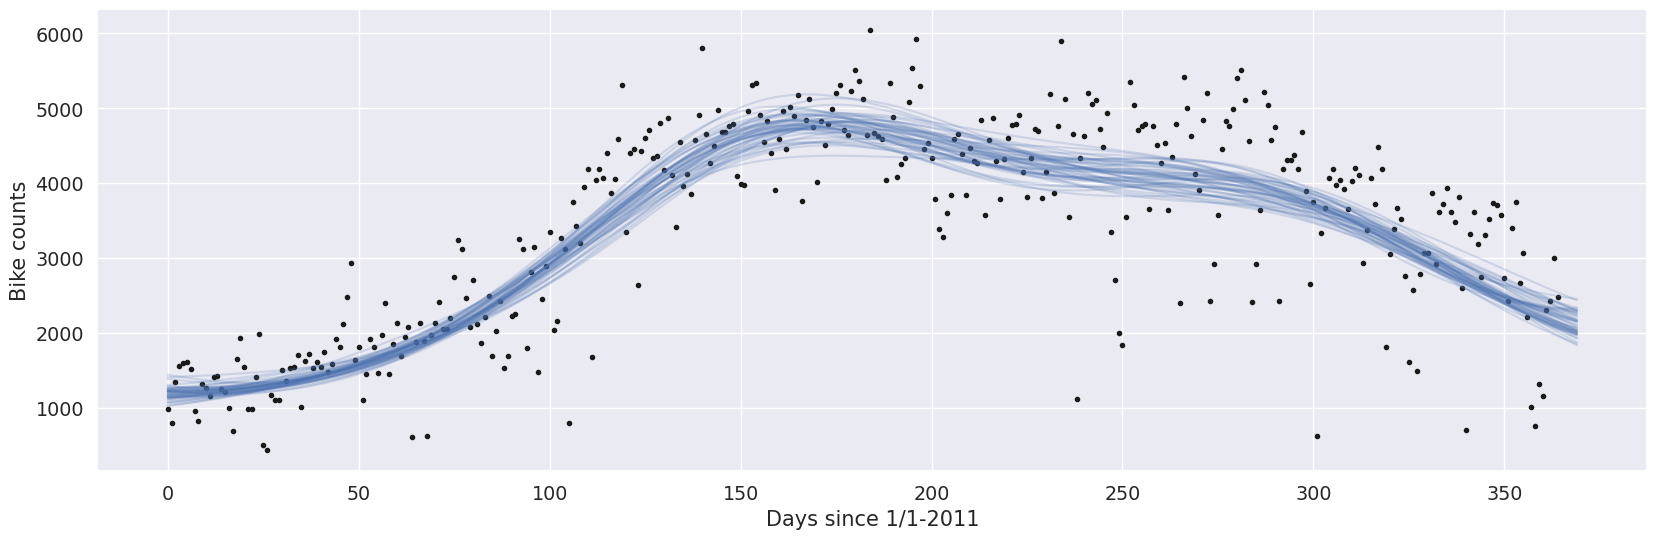

In [92]:
key = random.PRNGKey(42)
NUM_SAMPLES = 50

fig, ax = plt.subplots(1, 1, figsize=(20, 6))
samples = gp.posterior_samples( key=key, Xstar=x_star_bike, num_samples=NUM_SAMPLES )

samples_mean_var = ys * samples + ym 

samples_mean_var_exp = jnp.exp(samples_mean_var)




ax.plot(X, bike_count, 'k.', label='Preprocessed data')
ax.plot(Xstar, samples_mean_var_exp, 'b', alpha=0.2);
ax.set(xlabel='Days since 1/1-2011', ylabel='Bike counts');